In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import glob
from IPython.display import display

# With simple nonlinear interpoaltion but with altering volume to headspace ratio for the design of different microchambers

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from scipy.interpolate import Rbf
from ipywidgets import interact, FloatSlider, Dropdown

R = 8.314
R_Latm = 0.082057
ETA_ABP2 = 0.95
ETA_MPR = 0.875

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

csv_files = [f for f in glob(f"{folder}/M*.csv")]

data = {}
for f in csv_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()
    data[Path(f).stem] = df
    print(f"✓ Loaded: {Path(f).stem}")

meta = []
conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

for name, df in data.items():
    sample, temp_label, sensor = name.split('_')
    k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
    temp_K = df['Temperature (K)'].iloc[0]

    meta.append({
        'sample': sample,
        'conc': conc_map[sample],
        'temp_K': temp_K,
        'temp_C': temp_K - 273.15,
        'sensor': sensor,
        'k': df[k_col].iloc[0]
    })

meta = pd.DataFrame(meta)
print(meta)

meta_abp2 = meta[meta['sensor'] == 'ABP2']
rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
                function='multiquadric', smooth=0.1)

meta_mpr = meta[meta['sensor'] == 'MPR']
rbf_mpr = Rbf(meta_mpr['conc'], meta_mpr['temp_C'], meta_mpr['k'],
            function='multiquadric', smooth=0.1)

def predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL):
    k = rbf_abp2(conc_mM, temp_C) if sensor == 'ABP2' else rbf_mpr(conc_mM, temp_C)
    eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

    V_sol_L = V_sol_mL * 1e-3
    V_head_L = V_head_mL * 1e-3
    temp_K = temp_C + 273.15

    O2_theoretical_umol = conc_mM * V_sol_mL

    N0_mol = (conc_mM * 1e-3) * V_sol_L * eta
    N0_umol = N0_mol * 1e6

    Pmax_Pa = (N0_mol * R * temp_K) / (V_head_L * 1e-3)
    Pmax_kPa = Pmax_Pa / 1000.0

    t = np.linspace(0, 250, 1000)
    P_kPa = Pmax_kPa * (1 - np.exp(-k * t))
    O2_umol = ((P_kPa / 101.325) * V_head_L) / (R_Latm * temp_K) * 1e6

    return t, P_kPa, O2_umol, k, N0_umol, Pmax_kPa, O2_theoretical_umol

def interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2',
                        V_sol_mL=6.0, V_head_mL=4.0):
    t, P, O2, k, N0, Pmax, O2_theo = predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL)
    eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(t, P, 'b-', lw=2.5, label='Pressure')
    ax1.set_xlabel('Time (h)', fontsize=12)
    ax1.set_ylabel('Pressure (kPa)', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(t, O2, 'r--', lw=2.5, label='O₂')
    ax2.set_ylabel('O₂ released (µmol)', color='r', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='r')

    plt.title(f'{sensor} Sensor | {conc_mM:.2f} mM @ {temp_C:.1f}°C | '
            f'k={k:.4f} 1/h | η={eta:.2f}', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"{'─'*60}")
    print(f"Sensor: {sensor:5s} | k: {k:.4e} 1/h | η: {eta:.3f}")
    print(f"N₀: {N0:.2f} µmol | Pmax: {Pmax:.2f} kPa | Max O₂: {O2[-1]:.2f} µmol")
    print(f"Theoretical max O₂: {O2_theo:.2f} µmol (Conc × V_sol)")
    print(f"{'─'*60}")
print("\n" + "="*60)
print("EMPIRICAL O2 RELEASE MODEL - DUAL SENSOR")
print("="*60)
print(f"Loaded {len(data)} datasets")
print(f"ABP2 points: {len(meta_abp2)} | MPR points: {len(meta_mpr)}")
print(f"ABP2 η: {ETA_ABP2} | MPR η: {ETA_MPR}")
print("="*60)

interact(
    interactive_predict,
    conc_mM=FloatSlider(value=2.0, min=0.5, max=20.0, step=0.1, description='Conc (mM)'),
    temp_C=FloatSlider(value=25.0, min=20.0, max=50.0, step=0.5, description='Temp (°C)'),
    sensor=Dropdown(options=['ABP2', 'MPR'], value='ABP2', description='Sensor'),
    V_sol_mL=FloatSlider(value=6.0, min=1.0, max=20.0, step=0.5, description='V_sol (mL)'),
    V_head_mL=FloatSlider(value=4.0, min=1.0, max=20.0, step=0.5, description='V_head (mL)')
)

✓ Loaded: M1_RT_ABP2
✓ Loaded: M2_37C_ABP2
✓ Loaded: M2_37C_MPR
✓ Loaded: M2_RT_ABP2
✓ Loaded: M2_RT_MPR
✓ Loaded: M3_37C_ABP2
✓ Loaded: M3_37C_MPR
✓ Loaded: M3_RT_ABP2
✓ Loaded: M3_RT_MPR
✓ Loaded: M4_37C_ABP2
✓ Loaded: M4_37C_MPR
✓ Loaded: M4_RT_ABP2
✓ Loaded: M4_RT_MPR
   sample  conc      temp_K     temp_C sensor         k
0      M1  2.50  296.873987  23.723987   ABP2  0.015200
1      M2  2.18  309.268833  36.118833   ABP2  0.053500
2      M2  2.18  309.268833  36.118833    MPR  0.107400
3      M2  2.18  296.810000  23.660000   ABP2  0.012400
4      M2  2.18  296.920294  23.770294    MPR  0.014000
5      M3  1.20  309.874433  36.724433   ABP2  0.092700
6      M3  1.20  309.875100  36.725100    MPR  0.049100
7      M3  1.20  300.260000  27.110000   ABP2  0.032600
8      M3  1.20  300.269960  27.119960    MPR  0.033500
9      M4  1.60  309.990766  36.840766   ABP2  0.076071
10     M4  1.60  309.989532  36.839532    MPR  0.062900
11     M4  1.60  296.830000  23.680000   ABP2  0.015800

interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=20.0, min=0.5), FloatSlider(value=25…

<function __main__.interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2', V_sol_mL=6.0, V_head_mL=4.0)>

In [27]:
"""
Visualize how RBF interpolates k values across concentration and temperature
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from glob import glob
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D

# ============================================================================
# SETUP
# ============================================================================

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"
csv_files = sorted(glob(f"{folder}/M*_*_*.csv"))

conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

meta = []
for f in csv_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    filename = Path(f).stem
    sample, temp_label, sensor = filename.split('_')

    k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
    temp_K = df['Temperature (K)'].iloc[0]

    meta.append({
        'sample': sample,
        'conc': conc_map[sample],
        'temp_K': temp_K,
        'temp_C': temp_K - 273.15,
        'sensor': sensor,
        'k': df[k_col].iloc[0]
    })

meta = pd.DataFrame(meta)
meta_abp2 = meta[meta['sensor'] == 'ABP2']

# Build RBF interpolator
rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
               function='multiquadric', smooth=0.1)

print("✓ Setup complete!")
print(f"\nTraining data points (ABP2):")
print(meta_abp2[['sample', 'conc', 'temp_C', 'k']].to_string(index=False))

# ============================================================================
# GRAPH 1: k vs Concentration at different temperatures
# ============================================================================

def plot_k_vs_concentration():
    """Show how k is interpolated across concentration range at different temps"""

    fig, ax = plt.subplots(figsize=(12, 7))

    # Extended concentration range (1 to 20 mM)
    conc_range = np.linspace(1.0, 20.0, 200)

    # Different temperatures to show
    temps = [20, 24, 28, 30, 34, 37, 40]
    colors = plt.cm.plasma(np.linspace(0, 1, len(temps)))

    for temp, color in zip(temps, colors):
        k_values = []

        for conc in conc_range:
            try:
                k = rbf_abp2(conc, temp)
                k_values.append(k)
            except:
                k_values.append(np.nan)

        ax.plot(conc_range, k_values, linewidth=2.5, color=color,
               label=f'{temp}°C', alpha=0.8)

    # Mark training data points
    for temp_val in meta_abp2['temp_C'].unique():
        temp_subset = meta_abp2[meta_abp2['temp_C'] == temp_val]
        ax.scatter(temp_subset['conc'], temp_subset['k'],
                  s=150, c='red', marker='o', edgecolors='black',
                  linewidths=2, zorder=10)

    # Add vertical shaded region showing training range
    training_conc_min = meta_abp2['conc'].min()
    training_conc_max = meta_abp2['conc'].max()
    ax.axvspan(training_conc_min, training_conc_max, alpha=0.15,
              color='green', label='Available data range')

    # Add vertical line at max training concentration
    ax.axvline(x=training_conc_max, color='green', linestyle='--',
              linewidth=2, alpha=0.7, label=f'Max available data: {training_conc_max} mM')

    ax.set_xlabel('Concentration (mM)', fontsize=13, fontweight='bold')
    ax.set_ylabel('k (1/h)', fontsize=13, fontweight='bold')
    ax.set_title('RBF Interpolation of k vs Concentration\n(Red dots = Available data, beyond 2.5 mM = extrapolation)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10, ncol=2)
    ax.grid(alpha=0.3)

    # Add warning text for extrapolation zone
    ax.text(0.98, 0.95, '(Extrapolation)',
           transform=ax.transAxes, fontsize=11, color='red',
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
           fontweight='bold')

    plt.tight_layout()
    plt.savefig('k_interpolation_vs_concentration.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: k_interpolation_vs_concentration.png")
    print(f"Shows: How RBF interpolates k from {conc_range[0]:.1f} to {conc_range[-1]:.1f} mM")
    print(f"Available data range: {training_conc_min:.1f} - {training_conc_max:.1f} mM")
    print("WARNING: Beyond 2.5 mM is pure extrapolation (unreliable)")

# ============================================================================
# GRAPH 2: 3D surface showing k(concentration, temperature)
# ============================================================================

def plot_k_3d_surface():
    """3D surface showing k interpolation across both concentration and temperature"""

    fig = plt.figure(figsize=(16, 6))

    # Create concentration and temperature grids
    conc_range = np.linspace(1.0, 20.0, 80)
    temp_range = np.linspace(20, 40, 80)
    C, T = np.meshgrid(conc_range, temp_range)

    # Interpolate k values
    K_grid = np.zeros_like(C)
    for i in range(len(temp_range)):
        for j in range(len(conc_range)):
            try:
                K_grid[i,j] = rbf_abp2(C[i,j], T[i,j])
            except:
                K_grid[i,j] = np.nan

    # Plot 1: 3D surface
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    surf = ax1.plot_surface(C, T, K_grid, cmap='viridis', alpha=0.8,
                           edgecolor='none', antialiased=True)

    # Plot training points as red spheres
    ax1.scatter(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
               c='red', s=200, marker='o', edgecolors='black', linewidths=2,
               zorder=10, label='Training data')

    ax1.set_xlabel('Concentration (mM)', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_zlabel('k (1/h)', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_title('3D Surface: k(Conc, Temp)', fontsize=12, fontweight='bold')
    ax1.view_init(elev=25, azim=135)

    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

    # Plot 2: Heatmap view from top
    ax2 = fig.add_subplot(1, 2, 2)

    im = ax2.contourf(C, T, K_grid, levels=20, cmap='viridis')
    contours = ax2.contour(C, T, K_grid, levels=10, colors='white',
                          linewidths=0.5, alpha=0.4)
    ax2.clabel(contours, inline=True, fontsize=8, fmt='%.3f')

    # Mark training points
    ax2.scatter(meta_abp2['conc'], meta_abp2['temp_C'],
               c='red', s=200, marker='o', edgecolors='white', linewidths=2,
               zorder=10, label='Training data')

    # Draw training boundary
    from matplotlib.patches import Rectangle
    training_conc_min = meta_abp2['conc'].min()
    training_conc_max = meta_abp2['conc'].max()
    training_temp_min = meta_abp2['temp_C'].min()
    training_temp_max = meta_abp2['temp_C'].max()

    rect = Rectangle((training_conc_min, training_temp_min),
                     training_conc_max - training_conc_min,
                     training_temp_max - training_temp_min,
                     linewidth=3, edgecolor='lime', facecolor='none',
                     linestyle='--', label='Training boundary')
    ax2.add_patch(rect)

    ax2.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax2.set_title('Heatmap: k(Conc, Temp)\n(Green box = safe interpolation zone)',
                 fontsize=12, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=9)

    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('k (1/h)', fontsize=11, fontweight='bold')

    plt.suptitle('RBF Interpolation Surface for Rate Constant k',
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('k_interpolation_3d_surface.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: k_interpolation_3d_surface.png")
    print("Shows: Complete k interpolation landscape")
    print(f"Training range: Conc [{training_conc_min:.1f}, {training_conc_max:.1f}] mM")
    print(f"                Temp [{training_temp_min:.1f}, {training_temp_max:.1f}] °C")
    print("Outside green box = extrapolation (unreliable!)")

# ============================================================================
# GRAPH 3: k vs Temperature at different concentrations
# ============================================================================

def plot_k_vs_temperature():
    """Show how k changes with temperature at different concentrations"""

    fig, ax = plt.subplots(figsize=(12, 7))

    # Temperature range
    temp_range = np.linspace(20, 45, 200)

    # Different concentrations
    concentrations = [1.0, 1.2, 1.6, 2.0, 2.5, 5.0, 10.0, 15.0, 20.0]
    colors = plt.cm.RdYlGn(np.linspace(0, 1, len(concentrations)))

    for conc, color in zip(concentrations, colors):
        k_values = []

        for temp in temp_range:
            try:
                k = rbf_abp2(conc, temp)
                k_values.append(k)
            except:
                k_values.append(np.nan)

        linestyle = '-' if conc <= 2.5 else '--'
        linewidth = 2.5 if conc <= 2.5 else 2.0
        alpha = 0.9 if conc <= 2.5 else 0.5

        ax.plot(temp_range, k_values, linewidth=linewidth, color=color,
               linestyle=linestyle, label=f'{conc} mM', alpha=alpha)

    # Mark training data points
    for conc_val in meta_abp2['conc'].unique():
        conc_subset = meta_abp2[meta_abp2['conc'] == conc_val]
        ax.scatter(conc_subset['temp_C'], conc_subset['k'],
                  s=150, c='red', marker='o', edgecolors='black',
                  linewidths=2, zorder=10)

    # Shade training temperature range
    training_temp_min = meta_abp2['temp_C'].min()
    training_temp_max = meta_abp2['temp_C'].max()
    ax.axvspan(training_temp_min, training_temp_max, alpha=0.15,
              color='green', label='Training temp range')

    ax.set_xlabel('Temperature (°C)', fontsize=13, fontweight='bold')
    ax.set_ylabel('k (1/h)', fontsize=13, fontweight='bold')
    ax.set_title('RBF Interpolation of k vs Temperature\n(Solid lines = trained conc, Dashed = extrapolated conc)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(alpha=0.3)

    # Add annotation
    ax.text(0.98, 0.05, 'Red dots = Training data\nDashed lines = Extrapolation in concentration',
           transform=ax.transAxes, fontsize=10,
           verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig('k_interpolation_vs_temperature.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: k_interpolation_vs_temperature.png")
    print(f"Shows: How k changes with temperature at different concentrations")
    print(f"Training temp range: {training_temp_min:.1f} - {training_temp_max:.1f} °C")

# ============================================================================
# INSTRUCTIONS
# ============================================================================

print("\n" + "="*70)
print("K INTERPOLATION VISUALIZATION")
print("="*70)
print("\nplot_k_vs_concentration()  - k vs Conc (1-20 mM) at different temps")
print("plot_k_vs_temperature()    - k vs Temp at different concentrations")
print("plot_k_3d_surface()        - 3D surface + heatmap showing full landscape")
print("\nRun all:")
print("  plot_k_vs_concentration()")
print("  plot_k_vs_temperature()")
print("  plot_k_3d_surface()")
print("="*70)


✓ Setup complete!

Training data points (ABP2):
sample  conc    temp_C        k
    M1  2.50 23.723987 0.015200
    M2  2.18 36.118833 0.053500
    M2  2.18 23.660000 0.012400
    M3  1.20 36.724433 0.092700
    M3  1.20 27.110000 0.032600
    M4  1.60 36.840766 0.076071
    M4  1.60 23.680000 0.015800

K INTERPOLATION VISUALIZATION

plot_k_vs_concentration()  - k vs Conc (1-20 mM) at different temps
plot_k_vs_temperature()    - k vs Temp at different concentrations
plot_k_3d_surface()        - 3D surface + heatmap showing full landscape

Run all:
  plot_k_vs_concentration()
  plot_k_vs_temperature()
  plot_k_3d_surface()


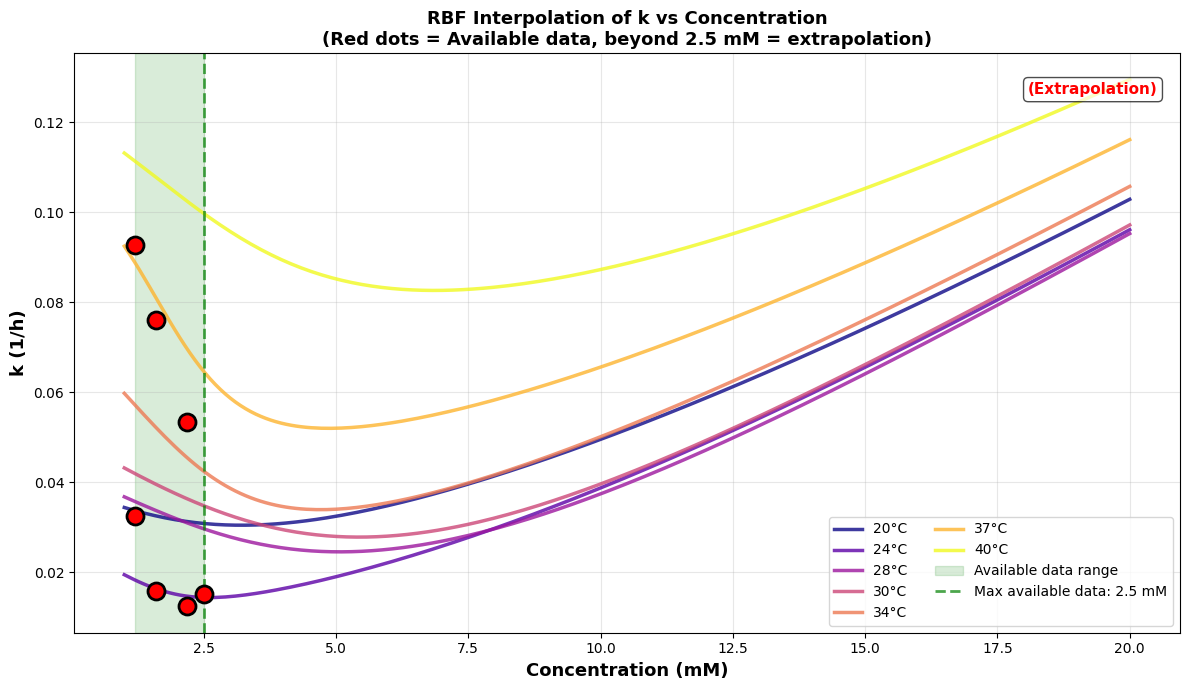


✓ Saved: k_interpolation_vs_concentration.png
Shows: How RBF interpolates k from 1.0 to 20.0 mM
Available data range: 1.2 - 2.5 mM


In [29]:
plot_k_vs_concentration()


In [38]:
"""
Visualize how RBF interpolates k values across concentration and temperature
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from glob import glob
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D

# ============================================================================
# SETUP
# ============================================================================

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"
csv_files = sorted(glob(f"{folder}/M*_*_*.csv"))

conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

meta = []
for f in csv_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    filename = Path(f).stem
    sample, temp_label, sensor = filename.split('_')

    k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
    temp_K = df['Temperature (K)'].iloc[0]

    meta.append({
        'sample': sample,
        'conc': conc_map[sample],
        'temp_K': temp_K,
        'temp_C': temp_K - 273.15,
        'sensor': sensor,
        'k': df[k_col].iloc[0]
    })

meta = pd.DataFrame(meta)
meta_abp2 = meta[meta['sensor'] == 'ABP2']

# Build RBF interpolator
rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
               function='multiquadric', smooth=0.1)

print("✓ Setup complete!")
print(f"\nTraining data points (ABP2):")
print(meta_abp2[['sample', 'conc', 'temp_C', 'k']].to_string(index=False))

# ============================================================================
# GRAPH 1: k vs Concentration at different temperatures
# ============================================================================

def plot_k_vs_concentration():
    """Show how k is interpolated across concentration range at different temps"""

    fig, ax = plt.subplots(figsize=(12, 7))

    # Reduced concentration range (1 to 10 mM)
    conc_range = np.linspace(1.0, 10.0, 200)

    # Different temperatures to show
    temps = [20, 24, 28, 30, 34, 37, 40]
    colors = plt.cm.plasma(np.linspace(0, 1, len(temps)))

    for temp, color in zip(temps, colors):
        k_values = []

        for conc in conc_range:
            try:
                k = rbf_abp2(conc, temp)
                k_values.append(k)
            except:
                k_values.append(np.nan)

        ax.plot(conc_range, k_values, linewidth=2.5, color=color,
               label=f'{temp}°C', alpha=0.8)

    # Mark training data points - separate by temperature
    # RT data points (~24°C)
    rt_subset = meta_abp2[meta_abp2['temp_C'] < 30]
    ax.scatter(rt_subset['conc'], rt_subset['k'],
              s=150, c='blue', marker='o', edgecolors='black',
              linewidths=2, zorder=10, label='K values at RT')

    # 37°C data points
    c37_subset = meta_abp2[meta_abp2['temp_C'] >= 30]
    ax.scatter(c37_subset['conc'], c37_subset['k'],
              s=150, c='red', marker='s', edgecolors='black',
              linewidths=2, zorder=10, label='K values at 37°C')

    # Add vertical shaded region showing training range
    training_conc_min = meta_abp2['conc'].min()
    training_conc_max = meta_abp2['conc'].max()
    ax.axvspan(training_conc_min, training_conc_max, alpha=0.15,
              color='green', label='Available data range')

    # Add vertical line at max training concentration
    ax.axvline(x=training_conc_max, color='green', linestyle='--',
              linewidth=2, alpha=0.7, label=f'Max available data: {training_conc_max} mM')

    ax.set_xlim(1.0, 10.0)
    ax.set_xlabel('Concentration (mM)', fontsize=13, fontweight='bold')
    ax.set_ylabel('k (1/h)', fontsize=13, fontweight='bold')
    ax.set_title('RBF Interpolation of k vs Concentration\n(Blue circles = RT data, Red squares = 37°C data, beyond 2.5 mM = extrapolation)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10, ncol=2)
    ax.grid(alpha=0.3)

    # Add warning text for extrapolation zone
    ax.text(0.98, 0.95, '(Extrapolation)',
           transform=ax.transAxes, fontsize=11, color='red',
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
           fontweight='bold')

    plt.tight_layout()
    plt.savefig('k_interpolation_vs_concentration.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: k_interpolation_vs_concentration.png")
    print(f"Shows: How RBF interpolates k from {conc_range[0]:.1f} to {conc_range[-1]:.1f} mM")
    print(f"Available data range: {training_conc_min:.1f} - {training_conc_max:.1f} mM")
    print("WARNING: Beyond 2.5 mM is pure extrapolation (unreliable)")

# ============================================================================
# GRAPH 2: 3D surface showing k(concentration, temperature)
# ============================================================================

def plot_k_3d_surface():
    """3D surface showing k interpolation across both concentration and temperature"""

    fig = plt.figure(figsize=(16, 6))

    # Create concentration and temperature grids
    conc_range = np.linspace(1.0, 20.0, 80)
    temp_range = np.linspace(20, 40, 80)
    C, T = np.meshgrid(conc_range, temp_range)

    # Interpolate k values
    K_grid = np.zeros_like(C)
    for i in range(len(temp_range)):
        for j in range(len(conc_range)):
            try:
                K_grid[i,j] = rbf_abp2(C[i,j], T[i,j])
            except:
                K_grid[i,j] = np.nan

    # Plot 1: 3D surface
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    surf = ax1.plot_surface(C, T, K_grid, cmap='viridis', alpha=0.8,
                           edgecolor='none', antialiased=True)

    # Plot training points as red spheres
    ax1.scatter(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
               c='red', s=200, marker='o', edgecolors='black', linewidths=2,
               zorder=10, label='Training data')

    ax1.set_xlabel('Concentration (mM)', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_zlabel('k (1/h)', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_title('3D Surface: k(Conc, Temp)', fontsize=12, fontweight='bold')
    ax1.view_init(elev=25, azim=135)

    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

    # Plot 2: Heatmap view from top
    ax2 = fig.add_subplot(1, 2, 2)

    im = ax2.contourf(C, T, K_grid, levels=20, cmap='viridis')
    contours = ax2.contour(C, T, K_grid, levels=10, colors='white',
                          linewidths=0.5, alpha=0.4)
    ax2.clabel(contours, inline=True, fontsize=8, fmt='%.3f')

    # Mark training points
    ax2.scatter(meta_abp2['conc'], meta_abp2['temp_C'],
               c='red', s=200, marker='o', edgecolors='white', linewidths=2,
               zorder=10, label='Training data')

    # Draw training boundary
    from matplotlib.patches import Rectangle
    training_conc_min = meta_abp2['conc'].min()
    training_conc_max = meta_abp2['conc'].max()
    training_temp_min = meta_abp2['temp_C'].min()
    training_temp_max = meta_abp2['temp_C'].max()

    rect = Rectangle((training_conc_min, training_temp_min),
                     training_conc_max - training_conc_min,
                     training_temp_max - training_temp_min,
                     linewidth=3, edgecolor='lime', facecolor='none',
                     linestyle='--', label='Training boundary')
    ax2.add_patch(rect)

    ax2.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax2.set_title('Heatmap: k(Conc, Temp)\n(Green box = safe interpolation zone)',
                 fontsize=12, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=9)

    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('k (1/h)', fontsize=11, fontweight='bold')

    plt.suptitle('RBF Interpolation Surface for Rate Constant k',
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('k_interpolation_3d_surface.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: k_interpolation_3d_surface.png")
    print("Shows: Complete k interpolation landscape")
    print(f"Training range: Conc [{training_conc_min:.1f}, {training_conc_max:.1f}] mM")
    print(f"                Temp [{training_temp_min:.1f}, {training_temp_max:.1f}] °C")
    print("Outside green box = extrapolation (unreliable!)")

# ============================================================================
# GRAPH 3: k vs Temperature at different concentrations
# ============================================================================

def plot_k_vs_temperature():
    """Show how k changes with temperature at different concentrations"""

    fig, ax = plt.subplots(figsize=(12, 7))

    # Temperature range
    temp_range = np.linspace(20, 45, 200)

    # Different concentrations
    concentrations = [1.0, 1.2, 1.6, 2.0, 2.5, 5.0, 10.0, 15.0, 20.0]
    colors = plt.cm.RdYlGn(np.linspace(0, 1, len(concentrations)))

    for conc, color in zip(concentrations, colors):
        k_values = []

        for temp in temp_range:
            try:
                k = rbf_abp2(conc, temp)
                k_values.append(k)
            except:
                k_values.append(np.nan)

        linestyle = '-' if conc <= 2.5 else '--'
        linewidth = 2.5 if conc <= 2.5 else 2.0
        alpha = 0.9 if conc <= 2.5 else 0.5

        ax.plot(temp_range, k_values, linewidth=linewidth, color=color,
               linestyle=linestyle, label=f'{conc} mM', alpha=alpha)

    # Mark training data points
    for conc_val in meta_abp2['conc'].unique():
        conc_subset = meta_abp2[meta_abp2['conc'] == conc_val]
        ax.scatter(conc_subset['temp_C'], conc_subset['k'],
                  s=150, c='red', marker='o', edgecolors='black',
                  linewidths=2, zorder=10)

    # Shade training temperature range
    training_temp_min = meta_abp2['temp_C'].min()
    training_temp_max = meta_abp2['temp_C'].max()
    ax.axvspan(training_temp_min, training_temp_max, alpha=0.15,
              color='green', label='Training temp range')

    ax.set_xlabel('Temperature (°C)', fontsize=13, fontweight='bold')
    ax.set_ylabel('k (1/h)', fontsize=13, fontweight='bold')
    ax.set_title('RBF Interpolation of k vs Temperature\n(Solid lines = trained conc, Dashed = extrapolated conc)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(alpha=0.3)

    # Add annotation
    ax.text(0.98, 0.05, 'Red dots = Training data\nDashed lines = Extrapolation in concentration',
           transform=ax.transAxes, fontsize=10,
           verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig('k_interpolation_vs_temperature.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: k_interpolation_vs_temperature.png")
    print(f"Shows: How k changes with temperature at different concentrations")
    print(f"Training temp range: {training_temp_min:.1f} - {training_temp_max:.1f} °C")

# ============================================================================
# INSTRUCTIONS
# ============================================================================

print("\n" + "="*70)
print("K INTERPOLATION VISUALIZATION")
print("="*70)
print("\nplot_k_vs_concentration()  - k vs Conc (1-20 mM) at different temps")
print("plot_k_vs_temperature()    - k vs Temp at different concentrations")
print("plot_k_3d_surface()        - 3D surface + heatmap showing full landscape")
print("\nRun all:")
print("  plot_k_vs_concentration()")
print("  plot_k_vs_temperature()")
print("  plot_k_3d_surface()")
print("="*70)


✓ Setup complete!

Training data points (ABP2):
sample  conc    temp_C        k
    M1  2.50 23.723987 0.015200
    M2  2.18 36.118833 0.053500
    M2  2.18 23.660000 0.012400
    M3  1.20 36.724433 0.092700
    M3  1.20 27.110000 0.032600
    M4  1.60 36.840766 0.076071
    M4  1.60 23.680000 0.015800

K INTERPOLATION VISUALIZATION

plot_k_vs_concentration()  - k vs Conc (1-20 mM) at different temps
plot_k_vs_temperature()    - k vs Temp at different concentrations
plot_k_3d_surface()        - 3D surface + heatmap showing full landscape

Run all:
  plot_k_vs_concentration()
  plot_k_vs_temperature()
  plot_k_3d_surface()


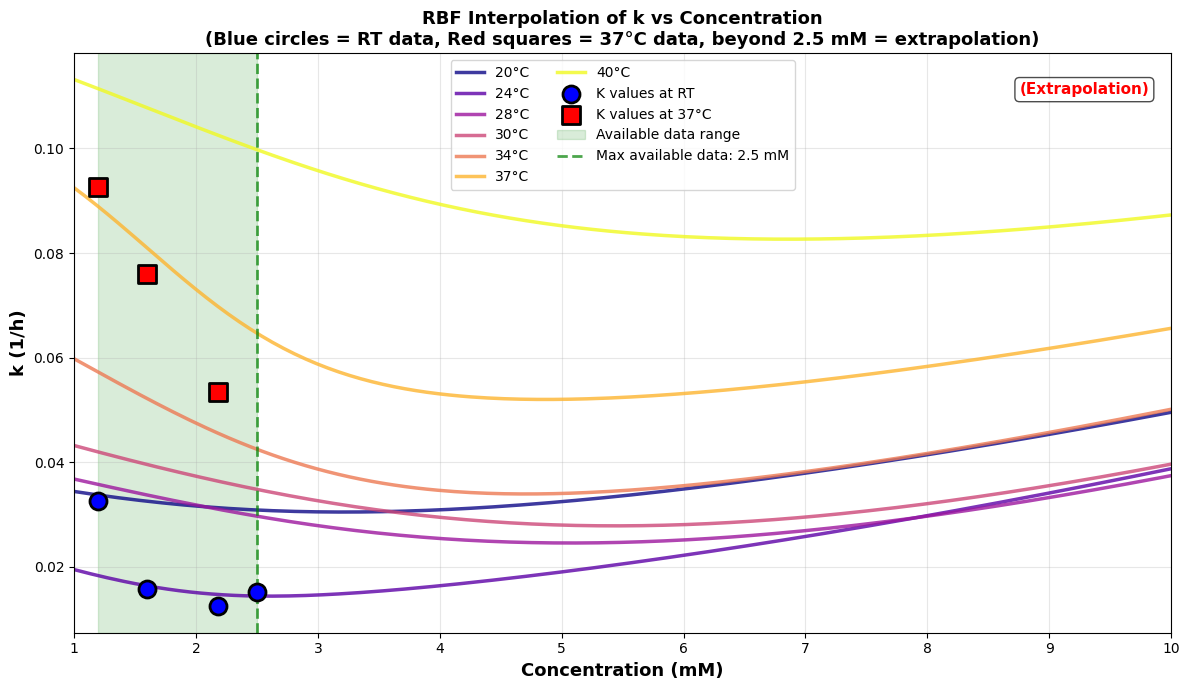


✓ Saved: k_interpolation_vs_concentration.png
Shows: How RBF interpolates k from 1.0 to 10.0 mM
Available data range: 1.2 - 2.5 mM


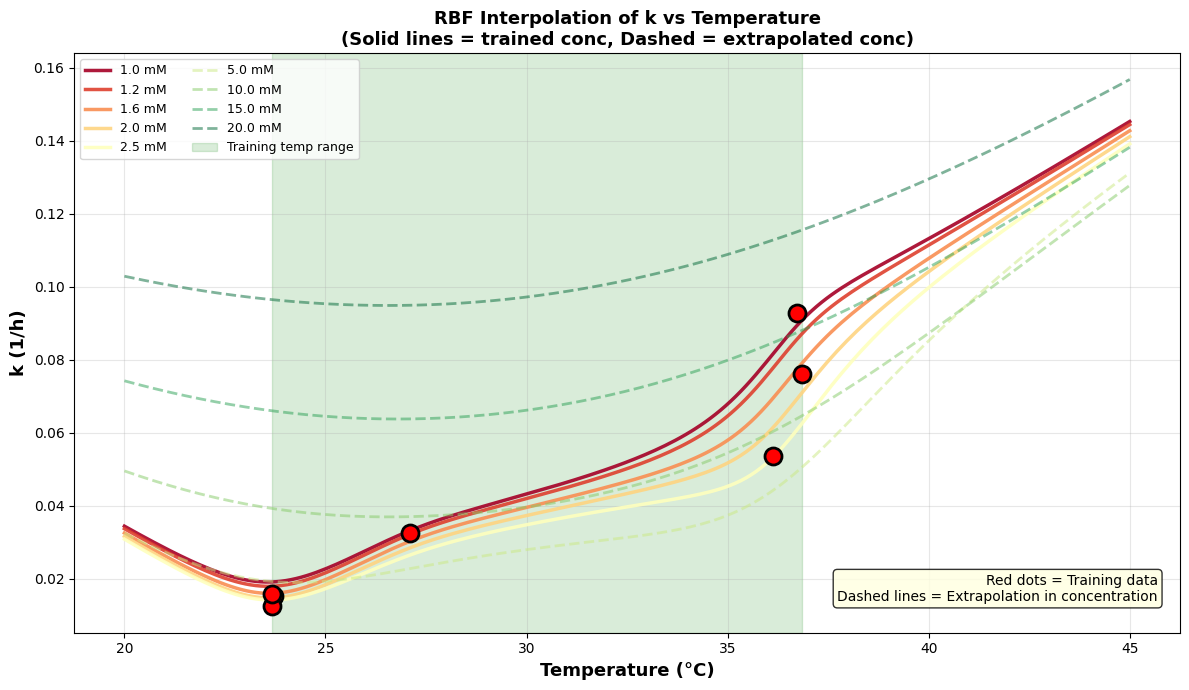


✓ Saved: k_interpolation_vs_temperature.png
Shows: How k changes with temperature at different concentrations
Training temp range: 23.7 - 36.8 °C


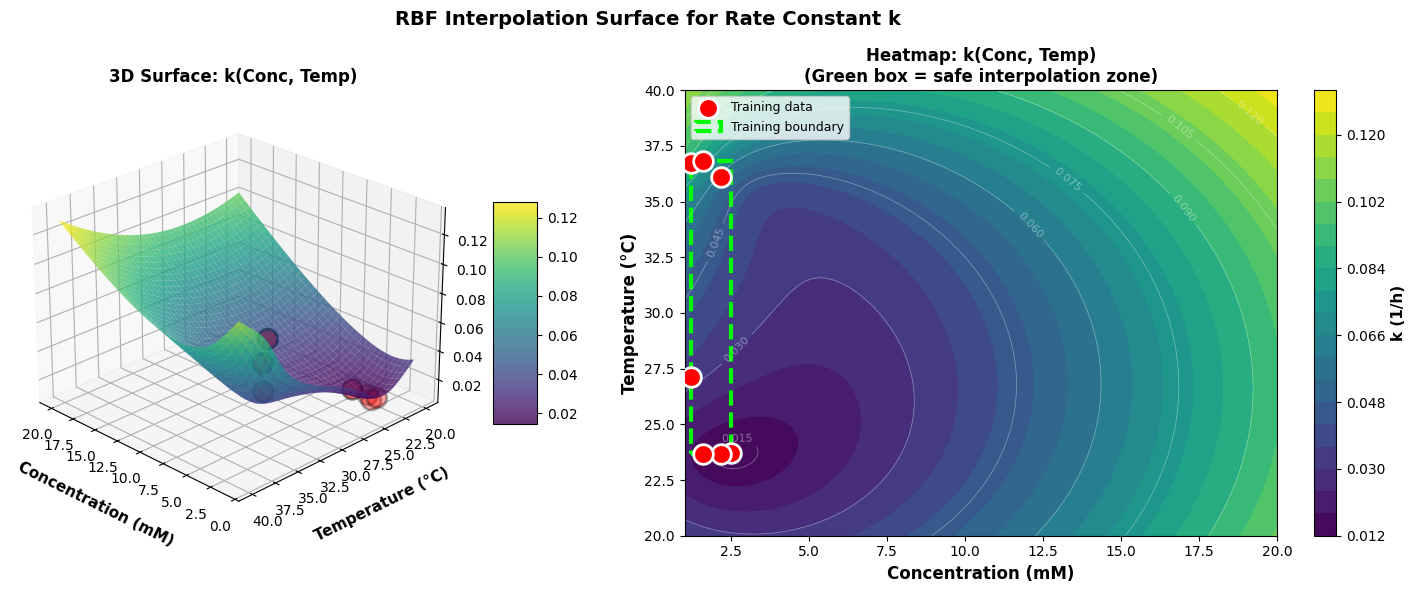


✓ Saved: k_interpolation_3d_surface.png
Shows: Complete k interpolation landscape
Training range: Conc [1.2, 2.5] mM
                Temp [23.7, 36.8] °C
Outside green box = extrapolation (unreliable!)


In [39]:
plot_k_vs_concentration()
plot_k_vs_temperature()
plot_k_3d_surface()

In [20]:
"""
Clean heatmap showing how V_sol affects max O₂ production
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from glob import glob
from pathlib import Path

# ============================================================================
# SETUP
# ============================================================================

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"
csv_files = sorted(glob(f"{folder}/M*_*_*.csv"))

conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}
ETA_ABP2 = 0.95
R = 8.314
R_Latm = 0.082057

meta = []
for f in csv_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    filename = Path(f).stem
    sample, temp_label, sensor = filename.split('_')

    k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
    temp_K = df['Temperature (K)'].iloc[0]

    meta.append({
        'sample': sample,
        'conc': conc_map[sample],
        'temp_K': temp_K,
        'temp_C': temp_K - 273.15,
        'sensor': sensor,
        'k': df[k_col].iloc[0]
    })

meta = pd.DataFrame(meta)
meta_abp2 = meta[meta['sensor'] == 'ABP2']

rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
               function='multiquadric', smooth=0.1)

def predict_max_o2(conc_mM, temp_C, V_sol_mL, V_head_mL):
    k = rbf_abp2(conc_mM, temp_C)
    V_sol_L = V_sol_mL * 1e-3
    V_head_L = V_head_mL * 1e-3
    temp_K = temp_C + 273.15

    N0_mol = (conc_mM * 1e-3) * V_sol_L * ETA_ABP2
    Pmax_Pa = (N0_mol * R * temp_K) / (V_head_L * 1e-3)
    Pmax_kPa = Pmax_Pa / 1000.0
    O2_max_umol = ((Pmax_kPa / 101.325) * V_head_L) / (R_Latm * temp_K) * 1e6

    return O2_max_umol

print("✓ Setup complete!")

# ============================================================================
# CLEAN VISUALIZATION: V_sol impact on max O₂
# ============================================================================

def plot_vsol_impact():
    """Clean heatmap: Concentration vs V_sol showing max O₂ (V_head fixed)"""

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    V_head = 4.0  # Fixed headspace volume (what matters is V_sol)
    temps = [24, 37]

    conc_range = np.linspace(1.0, 2.5, 80)
    vsol_range = np.linspace(2, 15, 80)

    for idx, temp in enumerate(temps):
        C, V = np.meshgrid(conc_range, vsol_range)
        O2_grid = np.zeros_like(C)

        for i in range(len(vsol_range)):
            for j in range(len(conc_range)):
                try:
                    O2_grid[i,j] = predict_max_o2(C[i,j], temp, V[i,j], V_head)
                except:
                    O2_grid[i,j] = np.nan

        # Clean heatmap without contours
        im = axes[idx].imshow(O2_grid, aspect='auto', origin='lower',
                             cmap='YlOrRd', interpolation='bilinear',
                             extent=[conc_range[0], conc_range[-1],
                                    vsol_range[0], vsol_range[-1]])

        # Mark experimental concentrations with subtle lines
        exp_concs = meta_abp2['conc'].unique()
        for ec in exp_concs:
            axes[idx].axvline(x=ec, color='navy', linestyle='--',
                            linewidth=1.5, alpha=0.4)

        # Mark typical V_sol = 6 mL
        axes[idx].axhline(y=6, color='white', linestyle='--',
                         linewidth=2, alpha=0.8)

        axes[idx].set_xlabel('Concentration (mM)', fontsize=13, fontweight='bold')
        axes[idx].set_ylabel('Solution Volume V_sol (mL)', fontsize=13, fontweight='bold')
        axes[idx].grid(False)

        # Colorbar
        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.set_label('Max O₂ Released (µmol)', fontsize=11, fontweight='bold')

    plt.suptitle(f'ABP2 Sensor: How V_sol Affects Max O₂ Production\n(V_head = {V_head} mL fixed)',
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('vsol_impact_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Saved: vsol_impact_heatmap.png")
    print(f"\nShows: Max O₂ vs Concentration and V_sol")
    print(f"- V_head fixed at {V_head} mL")
    print(f"- Vertical gradient = V_sol impact (linear scaling)")
    print(f"- Horizontal gradient = Concentration impact (via k)")
    print(f"- Dashed white line = typical V_sol (6 mL)")
    print(f"- Navy dashed lines = your experimental concentrations")

# ============================================================================
# INSTRUCTIONS
# ============================================================================

print("\n" + "="*70)
print("CLEAN V_SOL IMPACT VISUALIZATION")
print("="*70)
print("\nRun: plot_vsol_impact()")
print("="*70)


✓ Setup complete!

CLEAN V_SOL IMPACT VISUALIZATION

Run: plot_vsol_impact()


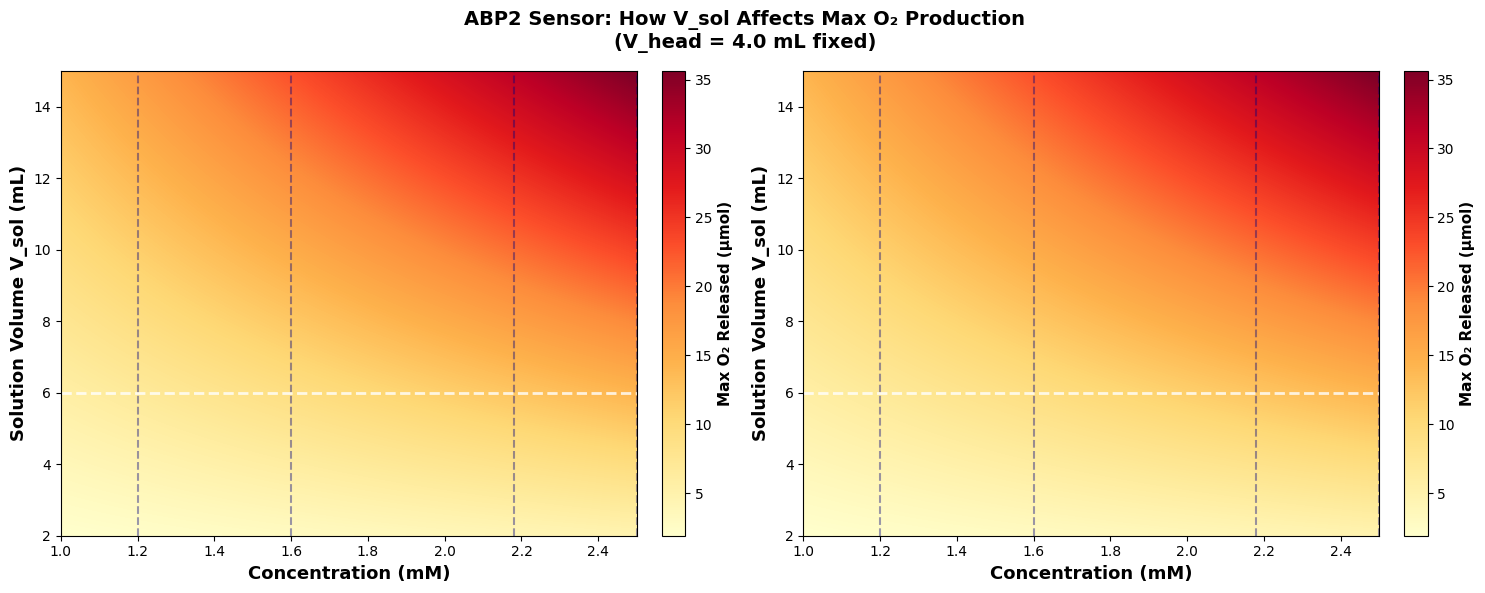

✓ Saved: vsol_impact_heatmap.png

Shows: Max O₂ vs Concentration and V_sol
- V_head fixed at 4.0 mL
- Vertical gradient = V_sol impact (linear scaling)
- Horizontal gradient = Concentration impact (via k)
- Dashed white line = typical V_sol (6 mL)
- Navy dashed lines = your experimental concentrations


In [21]:
plot_vsol_impact()

MODEL VALIDATION: ACTUAL vs ESTIMATED O2 RELEASE
Found 13 experiment files

Generating grid comparison...


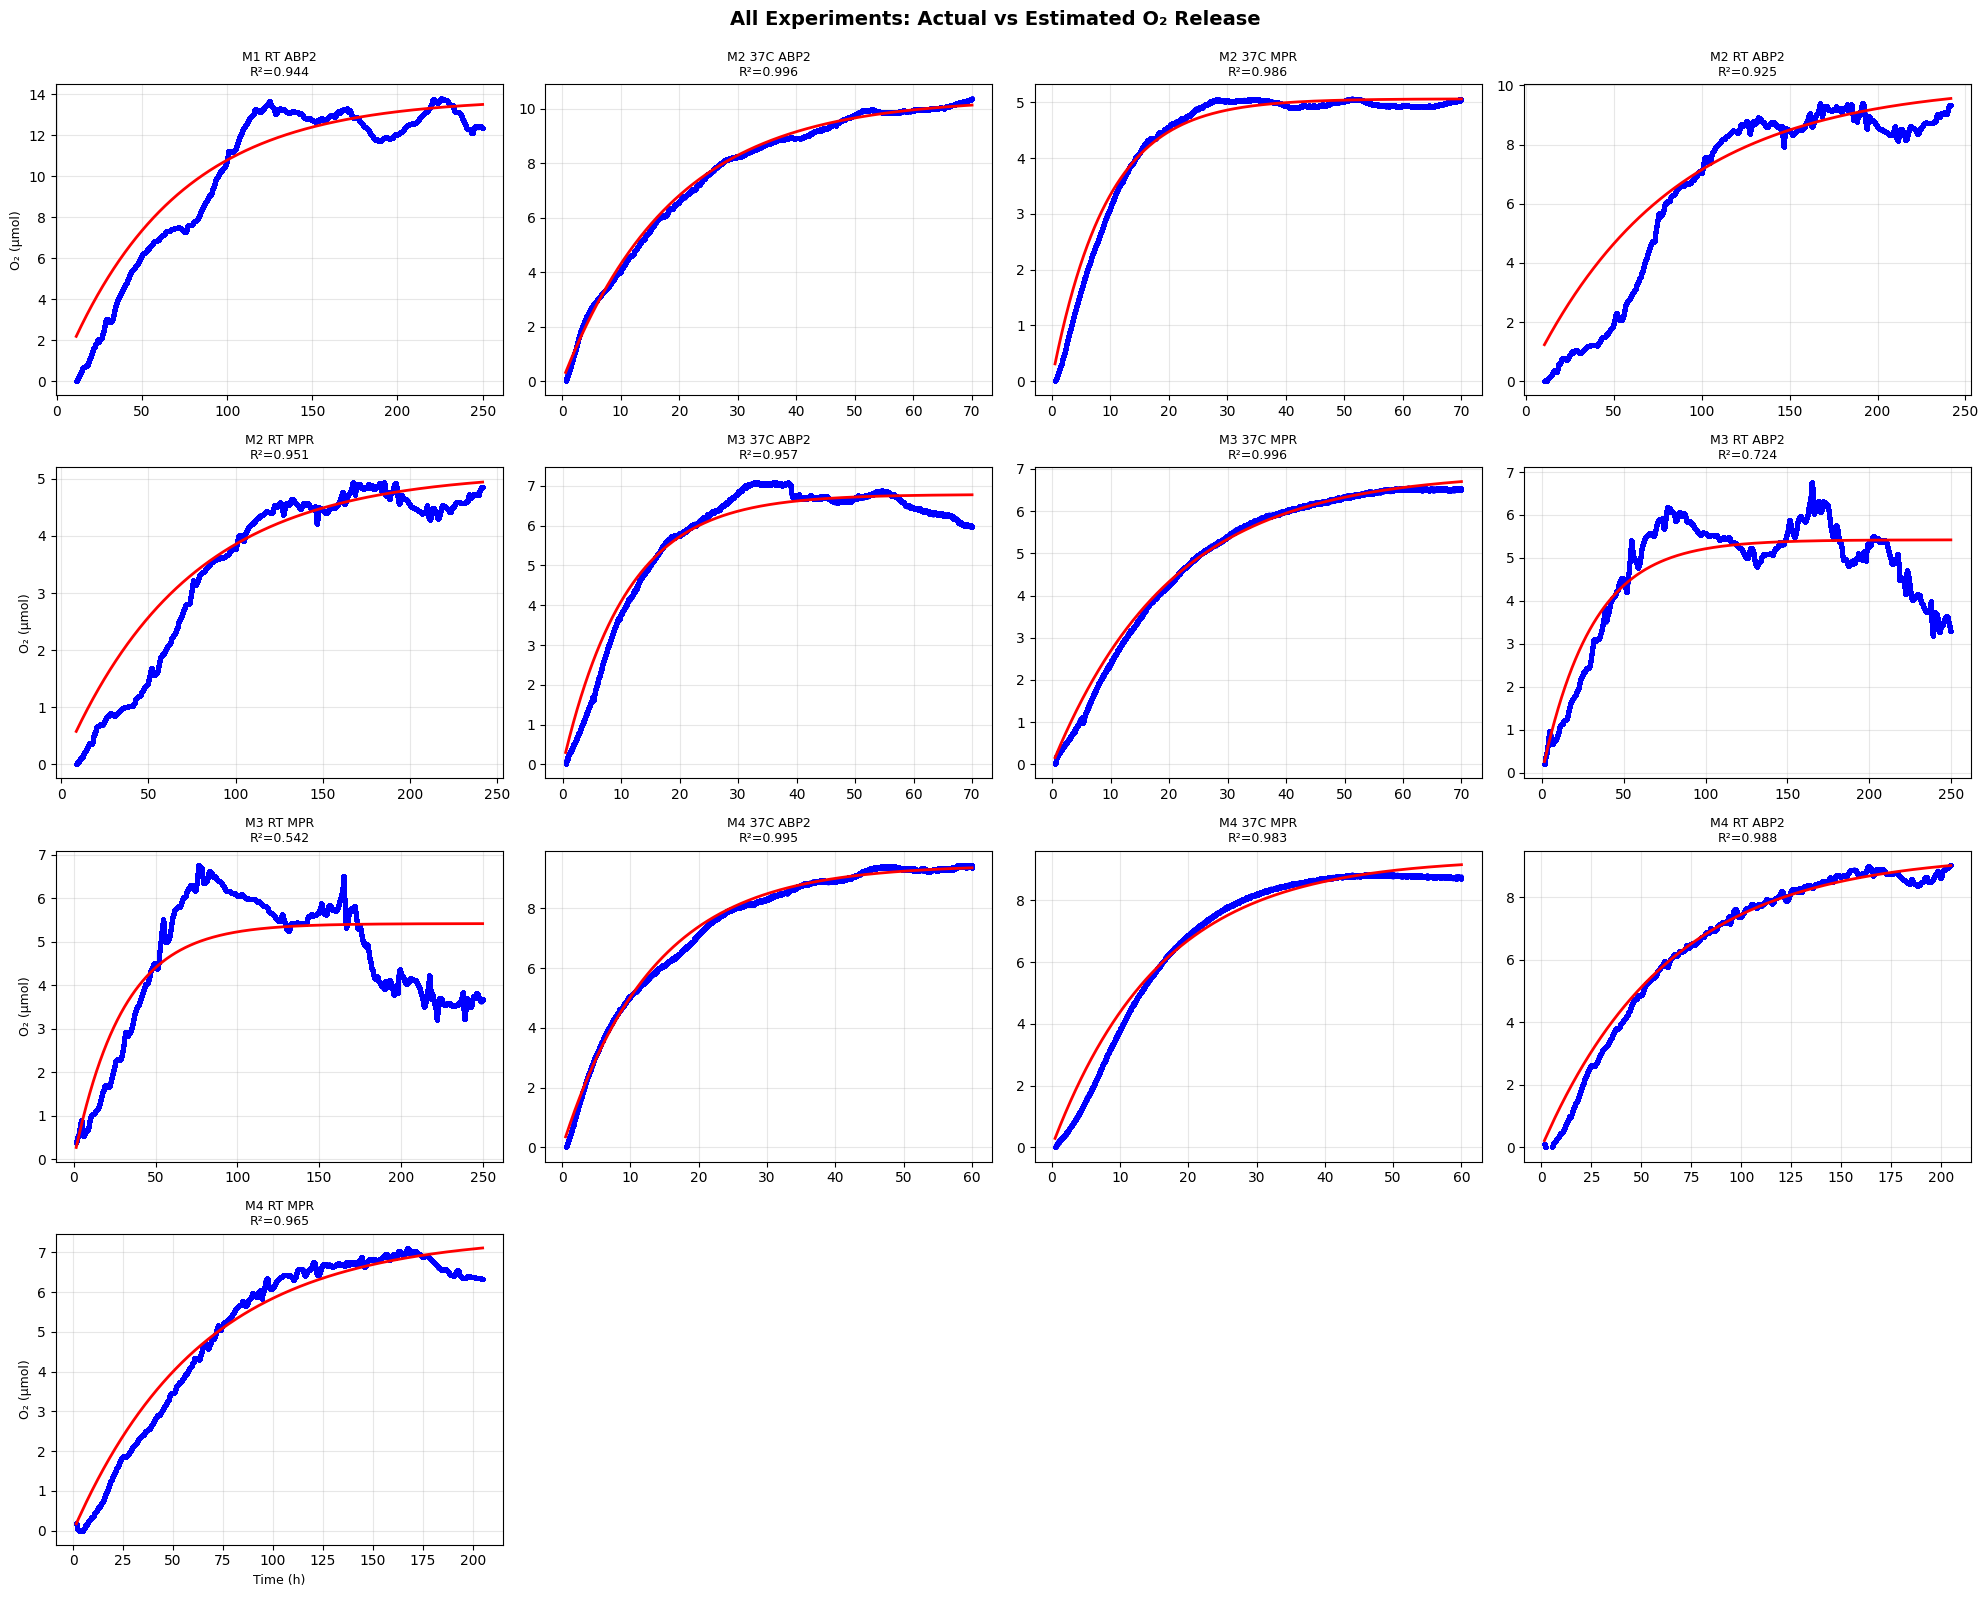


Done!


In [22]:
"""
Model Validation: Actual vs Estimated O2 Release Curves
========================================================
Compare experimental data with first-order kinetic model predictions
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

csv_files = sorted(glob(f"{folder}/M*_*_*.csv"))

conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

def plot_actual_vs_estimated(csv_file):
    name = Path(csv_file).stem
    sample, temp_label, sensor = name.split('_')

    df = pd.read_csv(csv_file, encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()

    time_col = [col for col in df.columns if 'Time (h)' in col][0]
    o2_col = [col for col in df.columns if 'O2 Released' in col][0]
    arr_k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
    arr_n0_col = [col for col in df.columns if 'ARR_FO-n0' in col][0]
    arr_rmse_col = [col for col in df.columns if 'ARR_FO-RMSE' in col][0]
    arr_r2_col = [col for col in df.columns if 'ARR_FO-R2' in col][0]

    t_actual = df[time_col].values
    o2_actual = df[o2_col].values

    k = df[arr_k_col].iloc[0]
    n0 = df[arr_n0_col].iloc[0]
    rmse = df[arr_rmse_col].iloc[0]
    r2 = df[arr_r2_col].iloc[0]

    o2_estimated = n0 * (1 - np.exp(-k * t_actual))

    residuals = o2_actual - o2_estimated

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8),
                                    gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(t_actual, o2_actual, 'o', markersize=3, alpha=0.5,
             color='blue', label='Actual (Experimental)')
    ax1.plot(t_actual, o2_estimated, '-', linewidth=2.5,
             color='red', label='Estimated (ARR_FO Model)')

    ax1.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
    ax1.set_title(f'{name} | {conc_map[sample]:.2f} mM @ {temp_label}\n'
                  f'k={k:.4f} 1/h | n₀={n0:.2f} µmol | R²={r2:.4f} | RMSE={rmse:.4f}',
                  fontsize=11, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)

    ax2.plot(t_actual, residuals, 'o', markersize=3, alpha=0.5, color='green')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.fill_between(t_actual, residuals, 0, alpha=0.3, color='green')
    ax2.set_xlabel('Time (h)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Residual (µmol)', fontsize=11, fontweight='bold')
    ax2.set_title('Residuals (Actual - Estimated)', fontsize=10)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'validation_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"{'='*70}")
    print(f"Validation: {name}")
    print(f"{'='*70}")
    print(f"Sample: {sample} | Conc: {conc_map[sample]} mM | Temp: {temp_label} | Sensor: {sensor}")
    print(f"Fitted parameters: k = {k:.6f} 1/h, n₀ = {n0:.4f} µmol")
    print(f"Model quality: R² = {r2:.4f}, RMSE = {rmse:.4f} µmol")
    print(f"Max residual: {np.abs(residuals).max():.4f} µmol")
    print(f"Mean absolute error: {np.abs(residuals).mean():.4f} µmol")
    print(f"{'='*70}\n")

    return {
        'name': name,
        'sample': sample,
        'conc': conc_map[sample],
        'temp': temp_label,
        'sensor': sensor,
        'k': k,
        'n0': n0,
        'r2': r2,
        'rmse': rmse,
        'mae': np.abs(residuals).mean()
    }

def plot_all_experiments_grid():
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    axes = axes.flatten()

    for idx, csv_file in enumerate(sorted(csv_files)):
        if idx >= 16:
            break

        try:
            name = Path(csv_file).stem
            sample, temp_label, sensor = name.split('_')

            df = pd.read_csv(csv_file, encoding='latin-1', low_memory=False)
            df.columns = df.columns.str.strip()

            time_col = [col for col in df.columns if 'Time (h)' in col][0]
            o2_col = [col for col in df.columns if 'O2 Released' in col][0]
            arr_k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
            arr_n0_col = [col for col in df.columns if 'ARR_FO-n0' in col][0]
            arr_r2_col = [col for col in df.columns if 'ARR_FO-R2' in col][0]

            t_actual = df[time_col].values
            o2_actual = df[o2_col].values
            k = df[arr_k_col].iloc[0]
            n0 = df[arr_n0_col].iloc[0]
            r2 = df[arr_r2_col].iloc[0]

            o2_estimated = n0 * (1 - np.exp(-k * t_actual))

            ax = axes[idx]
            ax.plot(t_actual, o2_actual, 'o', markersize=2, alpha=0.4, color='blue')
            ax.plot(t_actual, o2_estimated, '-', linewidth=2, color='red')
            ax.set_title(f'{sample} {temp_label} {sensor}\nR²={r2:.3f}', fontsize=9)
            ax.grid(alpha=0.3)

            if idx >= 12:
                ax.set_xlabel('Time (h)', fontsize=9)
            if idx % 4 == 0:
                ax.set_ylabel('O₂ (µmol)', fontsize=9)

        except Exception as e:
            ax = axes[idx]
            ax.text(0.5, 0.5, f'Error:\n{Path(csv_file).stem}',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])

    for idx in range(len(csv_files), 16):
        axes[idx].axis('off')

    plt.suptitle('All Experiments: Actual vs Estimated O₂ Release',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('validation_all_experiments.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_comparison_by_sensor():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for csv_file in sorted(csv_files):
        try:
            name = Path(csv_file).stem
            sample, temp_label, sensor = name.split('_')

            df = pd.read_csv(csv_file, encoding='latin-1', low_memory=False)
            df.columns = df.columns.str.strip()

            time_col = [col for col in df.columns if 'Time (h)' in col][0]
            o2_col = [col for col in df.columns if 'O2 Released' in col][0]

            t_actual = df[time_col].values
            o2_actual = df[o2_col].values

            if sensor == 'ABP2':
                ax = ax1
                color = 'blue' if temp_label == 'RT' else 'red'
            else:
                ax = ax2
                color = 'green' if temp_label == 'RT' else 'orange'

            ax.plot(t_actual, o2_actual, 'o', markersize=2, alpha=0.3, color=color,
                   label=f'{sample} {temp_label}')

        except Exception as e:
            print(f"Error: {name}")

    ax1.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
    ax1.set_title('ABP2 Sensor', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=8, ncol=2)
    ax1.grid(alpha=0.3)

    ax2.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
    ax2.set_title('MPR Sensor', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=8, ncol=2)
    ax2.grid(alpha=0.3)

    plt.suptitle('Model Validation by Sensor Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('validation_by_sensor.png', dpi=300, bbox_inches='tight')
    plt.show()

print("="*70)
print("MODEL VALIDATION: ACTUAL vs ESTIMATED O2 RELEASE")
print("="*70)
print(f"Found {len(csv_files)} experiment files")
print("="*70)

print("\nGenerating grid comparison...")
plot_all_experiments_grid()



print("\nDone!")
print("="*70)


Loading all curve data...
✓ M1_RT_ABP2
✓ M2_37C_ABP2
✓ M2_37C_MPR
✓ M2_RT_ABP2
✓ M2_RT_MPR
✓ M3_37C_ABP2
✓ M3_37C_MPR
✓ M3_RT_ABP2
✓ M3_RT_MPR
✓ M4_37C_ABP2
✓ M4_37C_MPR
✓ M4_RT_ABP2
✓ M4_RT_MPR

Loaded 13 curves

Generating Plot 1: n_estimated(t) at RT...


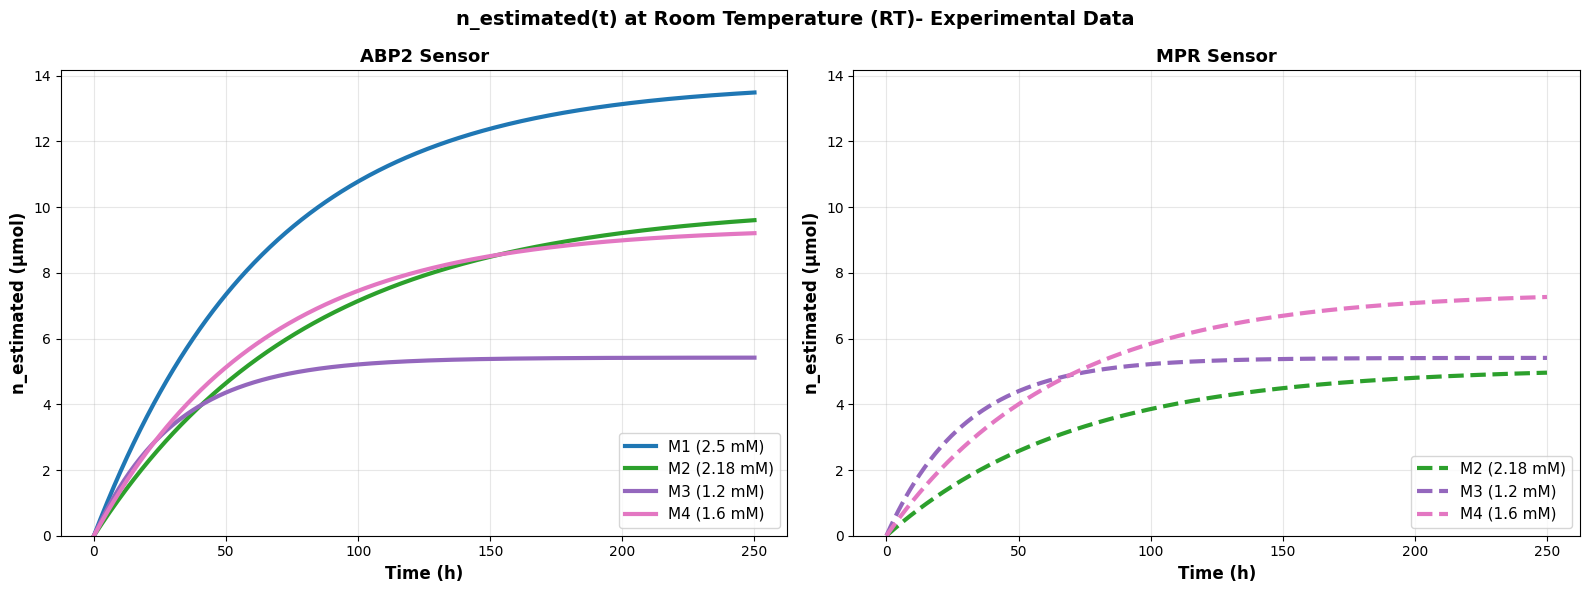

✓ Saved: estimated_curves_RT.png

Generating Plot 2: n_estimated(t) at 37°C...


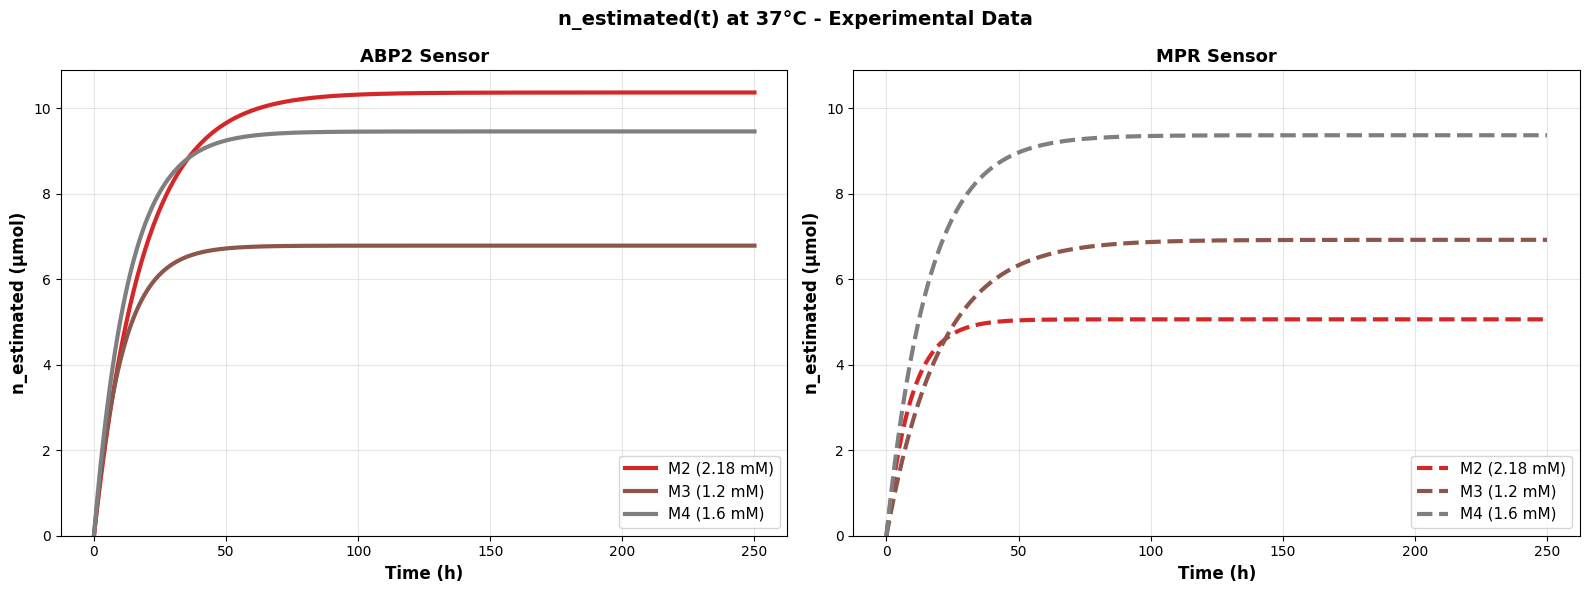

✓ Saved: estimated_curves_37C.png

Generating Plot 3: Actual O2 at RT...


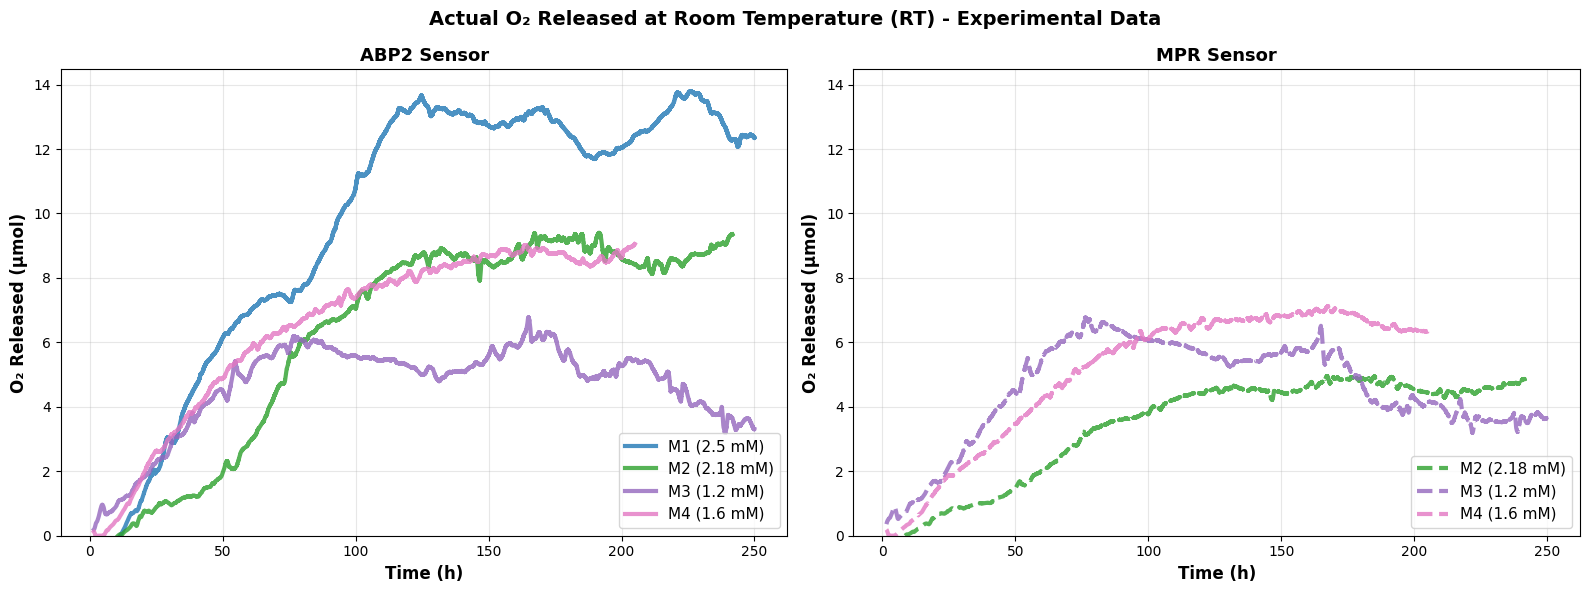

✓ Saved: actual_curves_RT.png

Generating Plot 4: Actual O2 at 37°C...


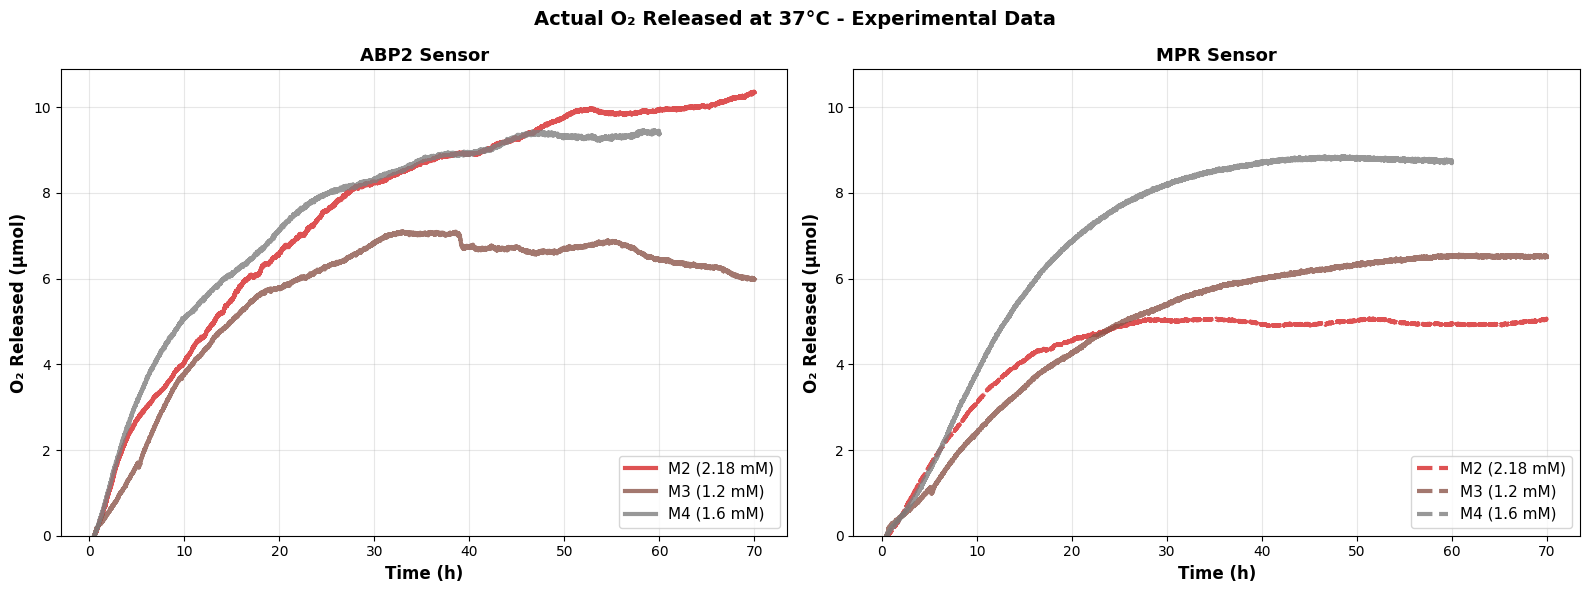

✓ Saved: actual_curves_37C.png

SUMMARY
Generated 4 plots (separate for RT and 37°C):

ESTIMATED CURVES (from Arrhenius first-order model):
  1. estimated_curves_RT.png - n_estimated(t) at Room Temperature
  2. estimated_curves_37C.png - n_estimated(t) at 37°C

ACTUAL CURVES (experimental data):
  3. actual_curves_RT.png - O₂ released at Room Temperature
  4. actual_curves_37C.png - O₂ released at 37°C

PLOT STRUCTURE:
  - Each plot has 2 panels: ABP2 (left) | MPR (right)
  - Each sample shown with its concentration in legend
  - Different colors for different samples


In [34]:
"""
Plot All n_estimated(t) Curves - Multiple Visualization Options
================================================================
Show all M1-M4 samples with both sensors in various layouts
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

csv_files = sorted(glob(f"{folder}/M*_*_*.csv"))

conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

# Color by (sample, temp) combination - same color for same experiment across sensors
experiment_colors = {
    ('M1', 'RT'): '#1f77b4',   # blue
    ('M1', '37C'): '#ff7f0e',  # orange
    ('M2', 'RT'): '#2ca02c',   # green
    ('M2', '37C'): '#d62728',  # red
    ('M3', 'RT'): '#9467bd',   # purple
    ('M3', '37C'): '#8c564b',  # brown
    ('M4', 'RT'): '#e377c2',   # pink
    ('M4', '37C'): '#7f7f7f',  # gray
}

def load_curve_data(csv_file):
    name = Path(csv_file).stem
    sample, temp_label, sensor = name.split('_')

    df = pd.read_csv(csv_file, encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()

    arr_k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
    arr_n0_col = [col for col in df.columns if 'ARR_FO-n0' in col][0]
    time_col = [col for col in df.columns if 'Time (h)' in col][0]
    o2_col = [col for col in df.columns if 'O2 Released' in col][0]

    k = df[arr_k_col].iloc[0]
    n0 = df[arr_n0_col].iloc[0]

    t_estimated = np.linspace(0, 250, 500)
    n_estimated = n0 * (1 - np.exp(-k * t_estimated))

    t_actual = df[time_col].values
    o2_actual = df[o2_col].values

    return {
        'sample': sample,
        'temp': temp_label,
        'sensor': sensor,
        'conc': conc_map[sample],
        'k': k,
        'n0': n0,
        't_est': t_estimated,
        'n_est': n_estimated,
        't_actual': t_actual,
        'o2_actual': o2_actual
    }

print("Loading all curve data...")
all_data = []
for csv_file in sorted(csv_files):
    try:
        data = load_curve_data(csv_file)
        all_data.append(data)
        print(f"✓ {data['sample']}_{data['temp']}_{data['sensor']}")
    except Exception as e:
        print(f"✗ {Path(csv_file).stem}: {e}")

print(f"\nLoaded {len(all_data)} curves")

# PLOT 1: Estimated O2 curves at RT
print("\nGenerating Plot 1: n_estimated(t) at RT...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Collect data and find max for y-axis scaling
rt_data_abp2 = []
rt_data_mpr = []

for data in all_data:
    if data['temp'] == 'RT':
        color = experiment_colors[(data['sample'], data['temp'])]
        linestyle = '-' if data['sensor'] == 'ABP2' else '--'
        linewidth = 3.0
        label = f"{data['sample']} ({data['conc']} mM)"

        if data['sensor'] == 'ABP2':
            ax1.plot(data['t_est'], data['n_est'], linestyle=linestyle,
                    color=color, linewidth=linewidth, label=label)
            rt_data_abp2.extend(data['n_est'])
        else:
            ax2.plot(data['t_est'], data['n_est'], linestyle=linestyle,
                    color=color, linewidth=linewidth, label=label)
            rt_data_mpr.extend(data['n_est'])

# Set same y-axis limits for both subplots
y_max = max(max(rt_data_abp2) if rt_data_abp2 else 0, max(rt_data_mpr) if rt_data_mpr else 0)
y_max = y_max * 1.05  # Add 5% padding

ax1.set_ylim(0, y_max)
ax2.set_ylim(0, y_max)

ax1.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax1.set_ylabel('n_estimated (µmol)', fontsize=12, fontweight='bold')
ax1.set_title('ABP2 Sensor', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(alpha=0.3)

ax2.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax2.set_ylabel('n_estimated (µmol)', fontsize=12, fontweight='bold')
ax2.set_title('MPR Sensor', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('n_estimated(t) at Room Temperature (RT)- Experimental Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('estimated_curves_RT.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: estimated_curves_RT.png")

# PLOT 2: Estimated O2 curves at 37C
print("\nGenerating Plot 2: n_estimated(t) at 37°C...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Collect data and find max for y-axis scaling
c37_data_abp2 = []
c37_data_mpr = []

for data in all_data:
    if data['temp'] == '37C':
        color = experiment_colors[(data['sample'], data['temp'])]
        linestyle = '-' if data['sensor'] == 'ABP2' else '--'
        linewidth = 3.0
        label = f"{data['sample']} ({data['conc']} mM)"

        if data['sensor'] == 'ABP2':
            ax1.plot(data['t_est'], data['n_est'], linestyle=linestyle,
                    color=color, linewidth=linewidth, label=label)
            c37_data_abp2.extend(data['n_est'])
        else:
            ax2.plot(data['t_est'], data['n_est'], linestyle=linestyle,
                    color=color, linewidth=linewidth, label=label)
            c37_data_mpr.extend(data['n_est'])

# Set same y-axis limits for both subplots
y_max = max(max(c37_data_abp2) if c37_data_abp2 else 0, max(c37_data_mpr) if c37_data_mpr else 0)
y_max = y_max * 1.05  # Add 5% padding

ax1.set_ylim(0, y_max)
ax2.set_ylim(0, y_max)

ax1.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax1.set_ylabel('n_estimated (µmol)', fontsize=12, fontweight='bold')
ax1.set_title('ABP2 Sensor', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(alpha=0.3)

ax2.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax2.set_ylabel('n_estimated (µmol)', fontsize=12, fontweight='bold')
ax2.set_title('MPR Sensor', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('n_estimated(t) at 37°C - Experimental Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('estimated_curves_37C.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: estimated_curves_37C.png")

# PLOT 3: Actual O2 curves at RT
print("\nGenerating Plot 3: Actual O2 at RT...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Collect data and find max for y-axis scaling
rt_actual_abp2 = []
rt_actual_mpr = []

for data in all_data:
    if data['temp'] == 'RT':
        color = experiment_colors[(data['sample'], data['temp'])]
        linestyle = '-' if data['sensor'] == 'ABP2' else '--'
        linewidth = 3.0
        label = f"{data['sample']} ({data['conc']} mM)"

        if data['sensor'] == 'ABP2':
            ax1.plot(data['t_actual'], data['o2_actual'], linestyle=linestyle,
                    color=color, linewidth=linewidth, alpha=0.8, label=label)
            rt_actual_abp2.extend(data['o2_actual'])
        else:
            ax2.plot(data['t_actual'], data['o2_actual'], linestyle=linestyle,
                    color=color, linewidth=linewidth, alpha=0.8, label=label)
            rt_actual_mpr.extend(data['o2_actual'])

# Set same y-axis limits for both subplots
y_max = max(max(rt_actual_abp2) if rt_actual_abp2 else 0, max(rt_actual_mpr) if rt_actual_mpr else 0)
y_max = y_max * 1.05  # Add 5% padding

ax1.set_ylim(0, y_max)
ax2.set_ylim(0, y_max)

ax1.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax1.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
ax1.set_title('ABP2 Sensor', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(alpha=0.3)

ax2.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax2.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
ax2.set_title('MPR Sensor', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('Actual O₂ Released at Room Temperature (RT) - Experimental Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_curves_RT.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: actual_curves_RT.png")

# PLOT 4: Actual O2 curves at 37C
print("\nGenerating Plot 4: Actual O2 at 37°C...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Collect data and find max for y-axis scaling
c37_actual_abp2 = []
c37_actual_mpr = []

for data in all_data:
    if data['temp'] == '37C':
        color = experiment_colors[(data['sample'], data['temp'])]
        linestyle = '-' if data['sensor'] == 'ABP2' else '--'
        linewidth = 3.0
        label = f"{data['sample']} ({data['conc']} mM)"

        if data['sensor'] == 'ABP2':
            ax1.plot(data['t_actual'], data['o2_actual'], linestyle=linestyle,
                    color=color, linewidth=linewidth, alpha=0.8, label=label)
            c37_actual_abp2.extend(data['o2_actual'])
        else:
            ax2.plot(data['t_actual'], data['o2_actual'], linestyle=linestyle,
                    color=color, linewidth=linewidth, alpha=0.8, label=label)
            c37_actual_mpr.extend(data['o2_actual'])

# Set same y-axis limits for both subplots
y_max = max(max(c37_actual_abp2) if c37_actual_abp2 else 0, max(c37_actual_mpr) if c37_actual_mpr else 0)
y_max = y_max * 1.05  # Add 5% padding

ax1.set_ylim(0, y_max)
ax2.set_ylim(0, y_max)

ax1.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax1.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
ax1.set_title('ABP2 Sensor', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(alpha=0.3)

ax2.set_xlabel('Time (h)', fontsize=12, fontweight='bold')
ax2.set_ylabel('O₂ Released (µmol)', fontsize=12, fontweight='bold')
ax2.set_title('MPR Sensor', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('Actual O₂ Released at 37°C - Experimental Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_curves_37C.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: actual_curves_37C.png")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print("Generated 4 plots (separate for RT and 37°C):")
print("\nESTIMATED CURVES (from Arrhenius first-order model):")
print("  1. estimated_curves_RT.png - n_estimated(t) at Room Temperature")
print("  2. estimated_curves_37C.png - n_estimated(t) at 37°C")
print("\nACTUAL CURVES (experimental data):")
print("  3. actual_curves_RT.png - O₂ released at Room Temperature")
print("  4. actual_curves_37C.png - O₂ released at 37°C")
print("\nPLOT STRUCTURE:")
print("  - Each plot has 2 panels: ABP2 (left) | MPR (right)")
print("  - Each sample shown with its concentration in legend")
print("  - Different colors for different samples")
print("="*70)


Loading and processing all data...
✓ M1_RT_ABP2
✓ M2_37C_ABP2
✓ M2_37C_MPR
✓ M2_RT_ABP2
✓ M2_RT_MPR
✓ M3_37C_ABP2
✓ M3_37C_MPR
✓ M3_RT_ABP2
✓ M3_RT_MPR
✓ M4_37C_ABP2
✓ M4_37C_MPR
✓ M4_RT_ABP2
✓ M4_RT_MPR

Processed 13 datasets

GENERATING COMPARISON PLOTS

Generating RT plots...


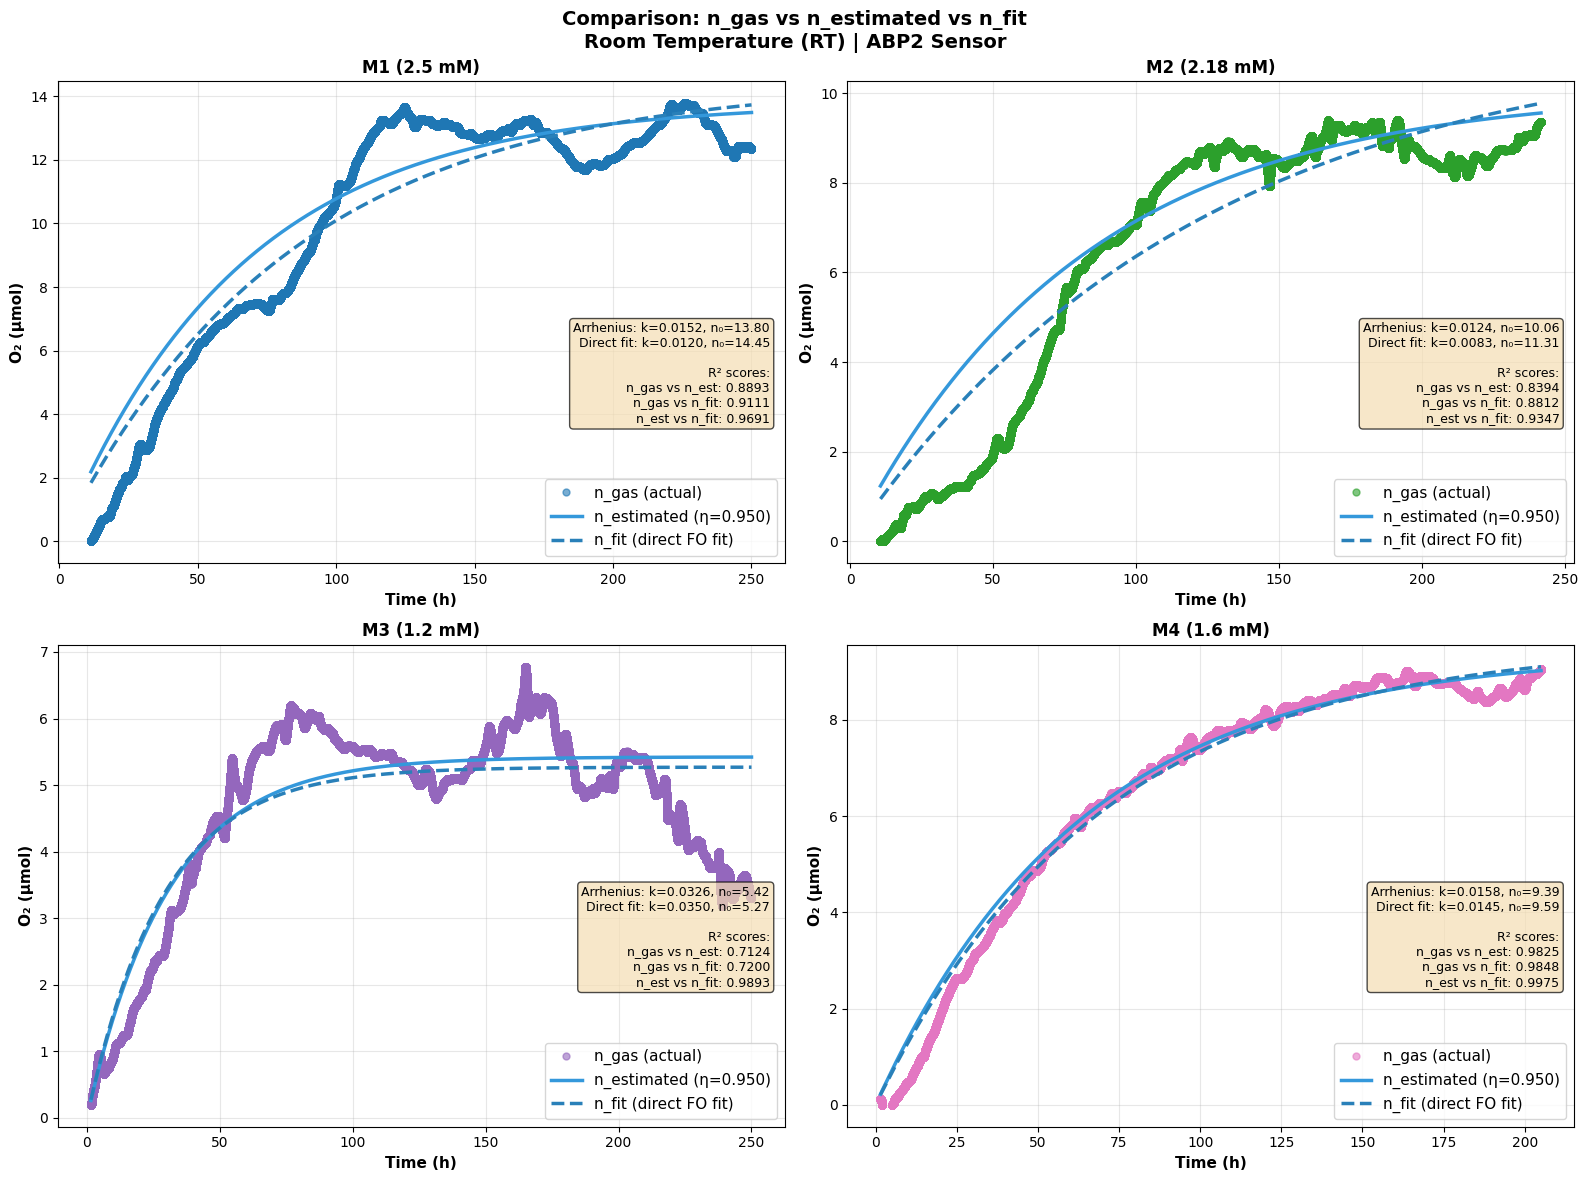

✓ Saved: comparison_ngas_nestimated_nfit_RT_ABP2.png


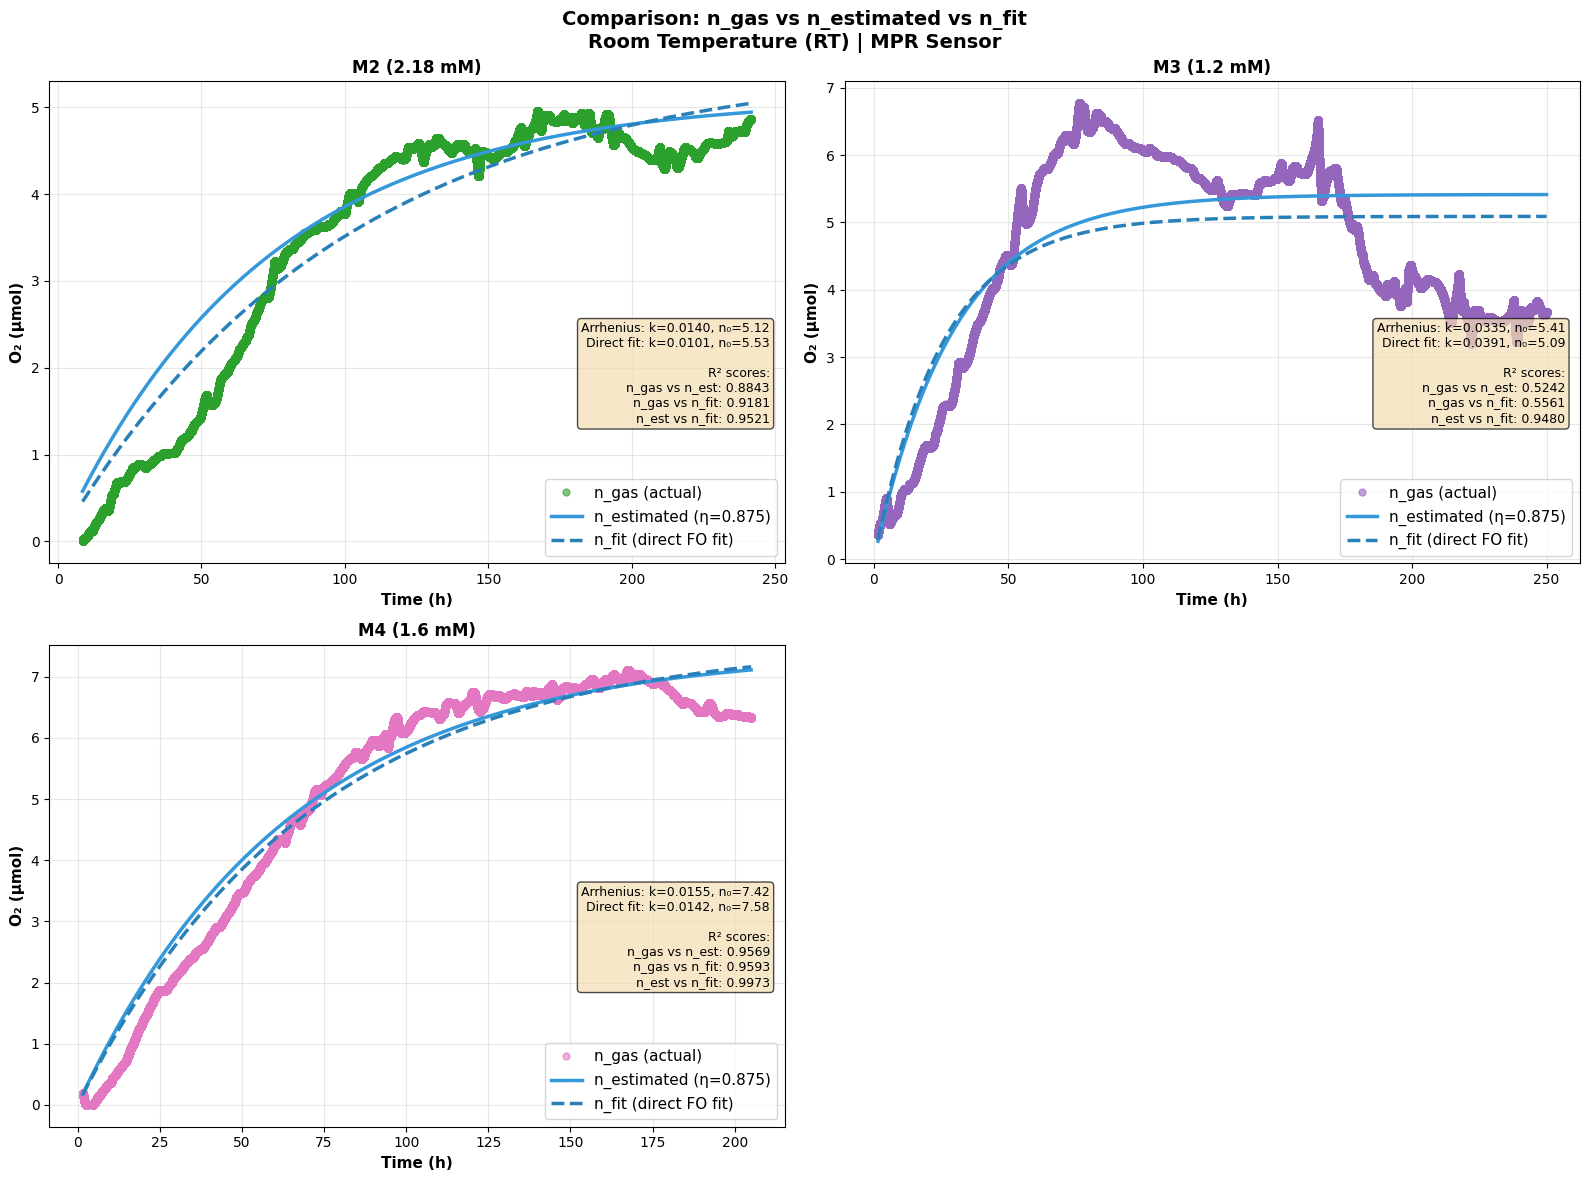

✓ Saved: comparison_ngas_nestimated_nfit_RT_MPR.png

Generating 37°C plots...


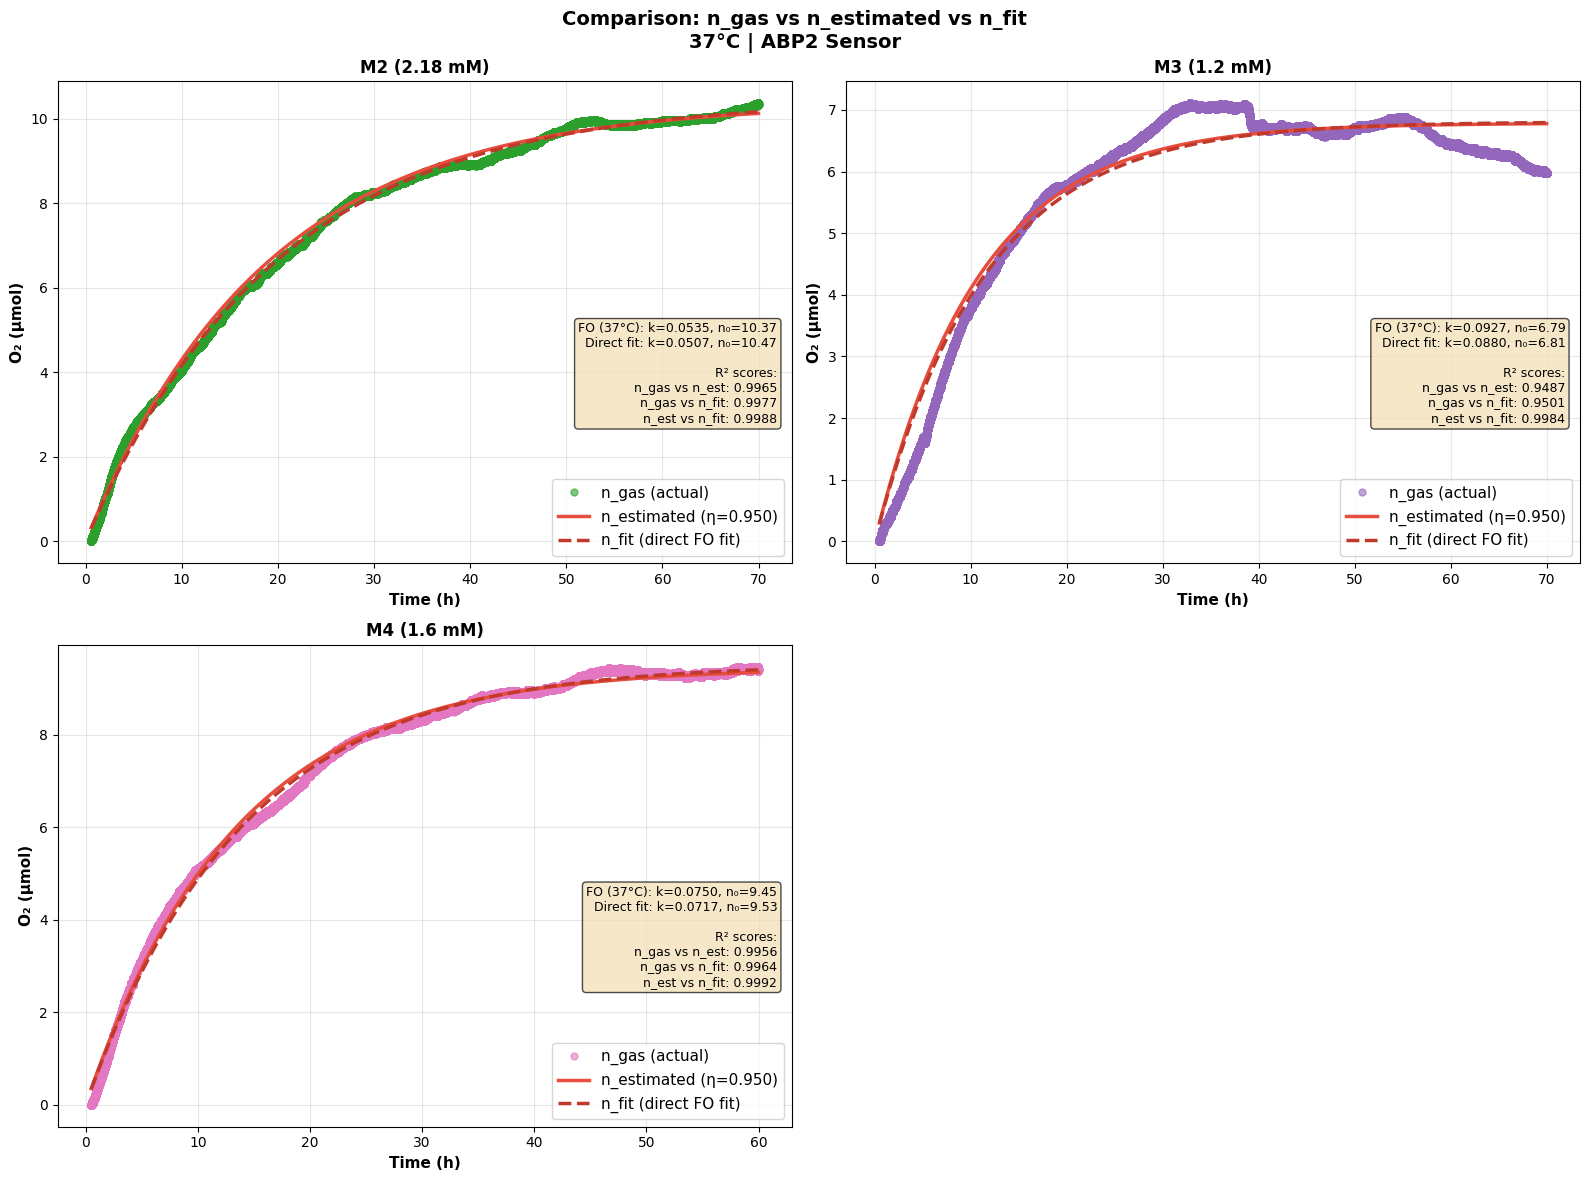

✓ Saved: comparison_ngas_nestimated_nfit_37C_ABP2.png


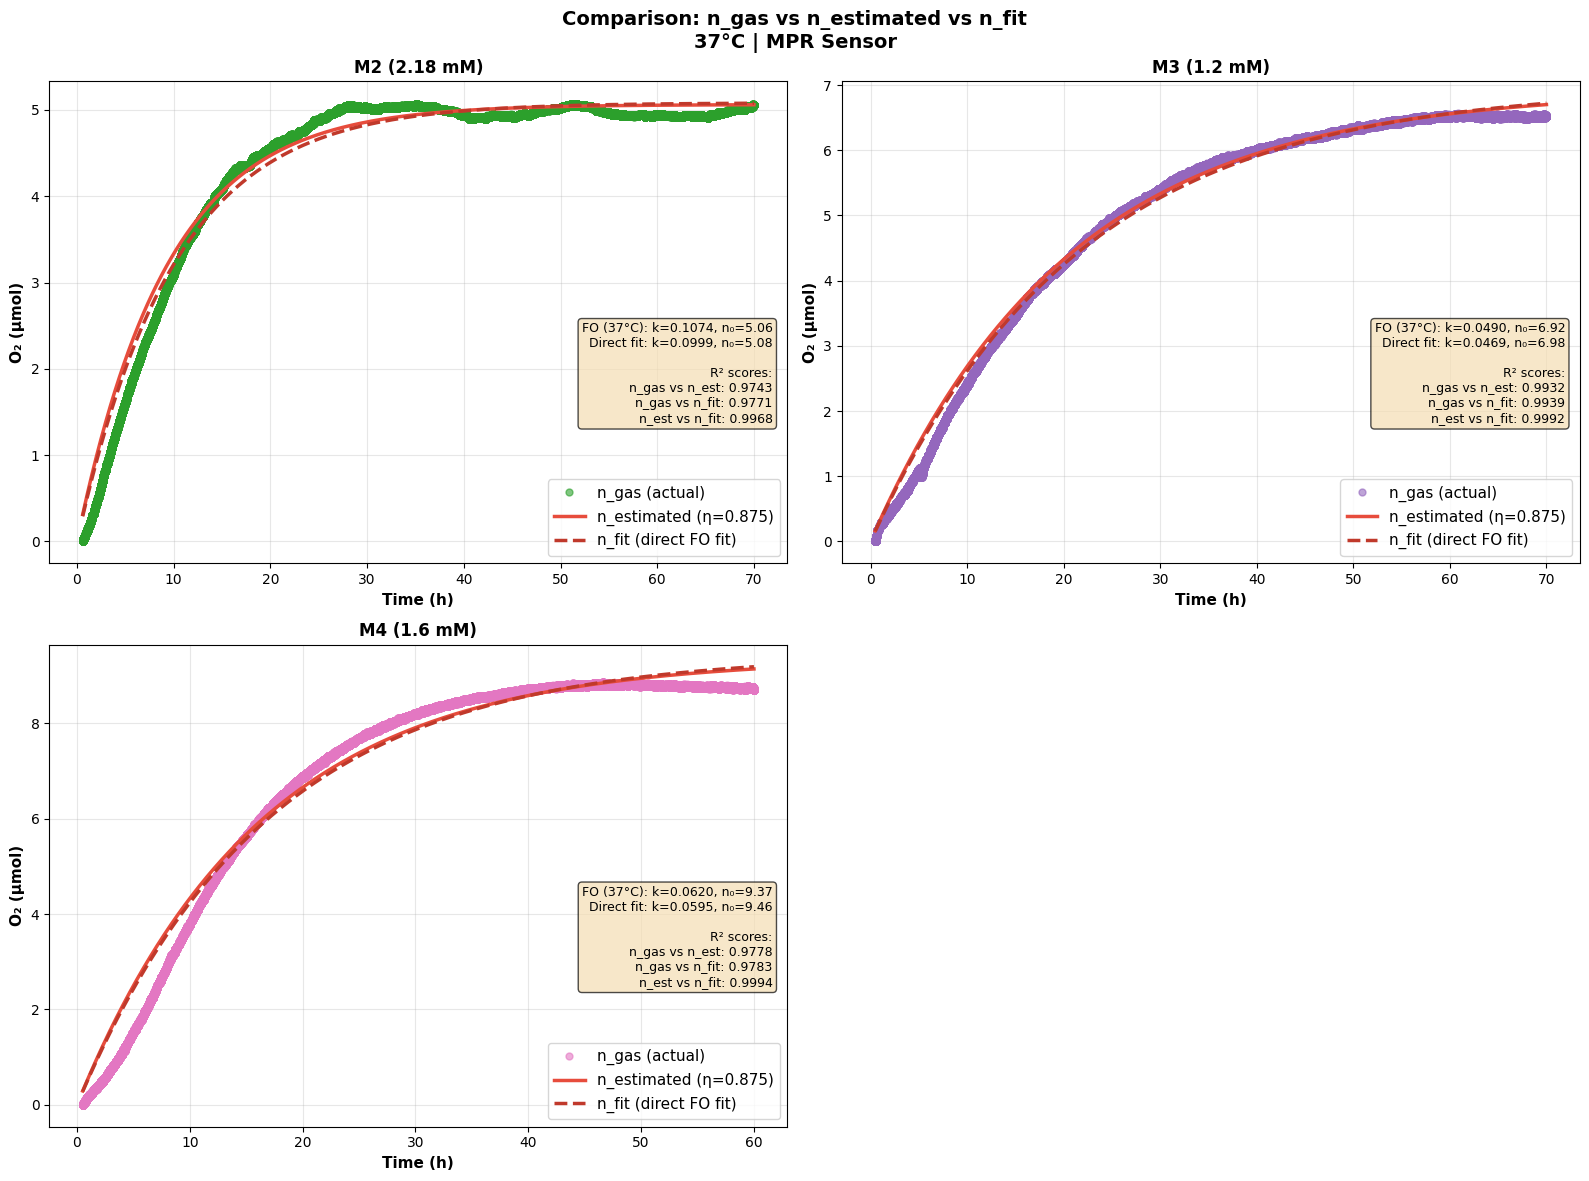

✓ Saved: comparison_ngas_nestimated_nfit_37C_MPR.png

R² SCORES SUMMARY TABLE

Sample Temp Sensor  Conc (mM)  R²(n_gas vs n_est)  R²(n_gas vs n_fit)  R²(n_est vs n_fit)
    M2  37C   ABP2       2.18            0.996516            0.997706            0.998785
    M3  37C   ABP2       1.20            0.948701            0.950147            0.998402
    M4  37C   ABP2       1.60            0.995619            0.996352            0.999230
    M2  37C    MPR       2.18            0.974252            0.977075            0.996815
    M3  37C    MPR       1.20            0.993153            0.993856            0.999250
    M4  37C    MPR       1.60            0.977839            0.978343            0.999448
    M1   RT   ABP2       2.50            0.889310            0.911117            0.969073
    M2   RT   ABP2       2.18            0.839374            0.881194            0.934696
    M3   RT   ABP2       1.20            0.712407            0.720023            0.989279
    M4   RT   ABP2   

In [44]:
"""
Compare n_gas (actual), n_estimated (with efficiency), and n_fit (direct first-order fit)
Separate plots for RT and 37C, and for ABP2 and MPR sensors
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# ============================================================================
# SETUP
# ============================================================================

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"
csv_files = sorted(glob(f"{folder}/M*_*_*.csv"))

conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

# Efficiencies
ETA_ABP2 = 0.95
ETA_MPR = 0.875

# Color scheme by sample
sample_colors = {
    'M1': '#1f77b4',  # blue
    'M2': '#2ca02c',  # green
    'M3': '#9467bd',  # purple
    'M4': '#e377c2',  # pink
}

def first_order_model(t, n0, k):
    """First-order kinetics: n(t) = n0 * (1 - exp(-k*t))"""
    return n0 * (1 - np.exp(-k * t))

def load_and_process_data(csv_file):
    """Load CSV and extract n_gas, n_estimated, and fit n_fit"""

    filename = Path(csv_file).stem
    sample, temp_label, sensor = filename.split('_')

    df = pd.read_csv(csv_file, encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()

    # Find columns
    time_col = [col for col in df.columns if 'Time (h)' in col][0]
    o2_col = [col for col in df.columns if 'O2 Released' in col][0]

    # For 37C: use normal FO-k, for RT: use ARR_FO-k
    if temp_label == '37C':
        k_col = [col for col in df.columns if 'FO-k (1/h)' in col and 'ARR' not in col][0]
        n0_col = [col for col in df.columns if 'FO-n0' in col and 'ARR' not in col][0]
    else:  # RT
        k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]
        n0_col = [col for col in df.columns if 'ARR_FO-n0' in col][0]

    # Extract data
    t_actual = df[time_col].values
    n_gas = df[o2_col].values  # Actual experimental O2
    k_model = df[k_col].iloc[0]
    n0_model = df[n0_col].iloc[0]

    # n_estimated: using model k and n0 with efficiency
    eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR
    n_estimated = n0_model * (1 - np.exp(-k_model * t_actual))

    # n_fit: Direct fit to n_gas using first-order model (curve_fit, NOT from CSV!)
    try:
        # Initial guess: n0 = max(n_gas), k = k_model
        p0 = [max(n_gas), k_model]
        popt, _ = curve_fit(first_order_model, t_actual, n_gas, p0=p0, maxfev=5000)
        n0_fit, k_fit = popt
        n_fit = first_order_model(t_actual, n0_fit, k_fit)
    except:
        # If fit fails, use NaN
        n_fit = np.full_like(n_gas, np.nan)
        n0_fit = np.nan
        k_fit = np.nan

    # Calculate R² scores
    try:
        r2_gas_est = r2_score(n_gas, n_estimated)  # R² between n_gas and n_estimated
    except:
        r2_gas_est = np.nan

    try:
        r2_gas_fit = r2_score(n_gas, n_fit)  # R² between n_gas and n_fit
    except:
        r2_gas_fit = np.nan

    try:
        r2_est_fit = r2_score(n_estimated, n_fit)  # R² between n_estimated and n_fit
    except:
        r2_est_fit = np.nan

    return {
        'sample': sample,
        'temp': temp_label,
        'sensor': sensor,
        'conc': conc_map[sample],
        't': t_actual,
        'n_gas': n_gas,
        'n_estimated': n_estimated,
        'n_fit': n_fit,
        'k_model': k_model,
        'n0_model': n0_model,
        'k_fit': k_fit,
        'n0_fit': n0_fit,
        'eta': eta,
        'r2_gas_est': r2_gas_est,
        'r2_gas_fit': r2_gas_fit,
        'r2_est_fit': r2_est_fit
    }

print("Loading and processing all data...")
all_data = []

for csv_file in csv_files:
    try:
        data = load_and_process_data(csv_file)
        all_data.append(data)
        print(f"✓ {data['sample']}_{data['temp']}_{data['sensor']}")
    except Exception as e:
        print(f"✗ {Path(csv_file).stem}: {e}")

print(f"\nProcessed {len(all_data)} datasets")

# ============================================================================
# PLOTTING FUNCTION
# ============================================================================

def plot_comparison(temp_label, sensor_type):
    """Create comparison plot for specific temperature and sensor"""

    # Filter data
    filtered_data = [d for d in all_data
                     if d['temp'] == temp_label and d['sensor'] == sensor_type]

    if not filtered_data:
        print(f"No data for {temp_label} {sensor_type}")
        return

    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    # Sort by sample
    filtered_data.sort(key=lambda x: x['sample'])

    # Color scheme based on temperature
    if temp_label == 'RT':
        n_estimated_color = '#3498db'  # Blue for RT
        n_fit_color = '#2980b9'  # Darker blue for RT
    else:  # 37C
        n_estimated_color = '#e74c3c'  # Red for 37C
        n_fit_color = '#c0392b'  # Darker red for 37C

    for idx, data in enumerate(filtered_data):
        if idx >= 4:  # Only 4 subplots
            break

        ax = axes[idx]
        color = sample_colors[data['sample']]

        # Plot n_gas (actual experimental data)
        ax.plot(data['t'], data['n_gas'], 'o', markersize=5,
               color=color, alpha=0.6, label='n_gas (actual)')

        # Plot n_estimated (from model with efficiency)
        ax.plot(data['t'], data['n_estimated'], '-', linewidth=2.5,
               color=n_estimated_color, label=f'n_estimated (η={data["eta"]:.3f})')

        # Plot n_fit (direct first-order fit to n_gas)
        ax.plot(data['t'], data['n_fit'], '--', linewidth=2.5,
               color=n_fit_color, label='n_fit (direct FO fit)')

        # Labels and title
        ax.set_xlabel('Time (h)', fontsize=11, fontweight='bold')
        ax.set_ylabel('O₂ (µmol)', fontsize=11, fontweight='bold')
        ax.set_title(f'{data["sample"]} ({data["conc"]} mM)',
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=11, loc='lower right')
        ax.grid(alpha=0.3)

        # Add text box with fit parameters and R² scores (larger font)
        # Position in upper right, outside the main curve area
        model_label = 'Arrhenius' if temp_label == 'RT' else 'FO (37°C)'
        textstr = f'{model_label}: k={data["k_model"]:.4f}, n₀={data["n0_model"]:.2f}\n'
        textstr += f'Direct fit: k={data["k_fit"]:.4f}, n₀={data["n0_fit"]:.2f}\n'
        textstr += f'\nR² scores:\n'
        textstr += f'  n_gas vs n_est: {data["r2_gas_est"]:.4f}\n'
        textstr += f'  n_gas vs n_fit: {data["r2_gas_fit"]:.4f}\n'
        textstr += f'  n_est vs n_fit: {data["r2_est_fit"]:.4f}'
        ax.text(0.98, 0.50, textstr, transform=ax.transAxes,
               fontsize=9, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # Hide unused subplots
    for idx in range(len(filtered_data), 4):
        axes[idx].axis('off')

    # Overall title
    temp_display = 'Room Temperature (RT)' if temp_label == 'RT' else '37°C'
    plt.suptitle(f'Comparison: n_gas vs n_estimated vs n_fit\n{temp_display} | {sensor_type} Sensor',
                fontsize=14, fontweight='bold')
    plt.tight_layout()

    # Save
    filename = f'comparison_ngas_nestimated_nfit_{temp_label}_{sensor_type}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: {filename}")

# ============================================================================
# GENERATE ALL PLOTS
# ============================================================================

print("\n" + "="*70)
print("GENERATING COMPARISON PLOTS")
print("="*70)

# RT plots
print("\nGenerating RT plots...")
plot_comparison('RT', 'ABP2')
plot_comparison('RT', 'MPR')

# 37C plots
print("\nGenerating 37°C plots...")
plot_comparison('37C', 'ABP2')
plot_comparison('37C', 'MPR')

# ============================================================================
# R² SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("R² SCORES SUMMARY TABLE")
print("="*70)

# Create DataFrame for R² scores
r2_data = []
for data in all_data:
    r2_data.append({
        'Sample': data['sample'],
        'Temp': data['temp'],
        'Sensor': data['sensor'],
        'Conc (mM)': data['conc'],
        'R²(n_gas vs n_est)': data['r2_gas_est'],
        'R²(n_gas vs n_fit)': data['r2_gas_fit'],
        'R²(n_est vs n_fit)': data['r2_est_fit']
    })

r2_df = pd.DataFrame(r2_data)

# Sort by temperature and sensor
r2_df = r2_df.sort_values(['Temp', 'Sensor', 'Sample'])

print("\n" + r2_df.to_string(index=False))

# Save to CSV
r2_df.to_csv('r2_scores_summary.csv', index=False)
print("\n✓ Saved R² scores to: r2_scores_summary.csv")

# Calculate and display average R² scores by temperature and sensor
print("\n" + "="*70)
print("AVERAGE R² SCORES BY TEMPERATURE AND SENSOR")
print("="*70)

avg_r2 = r2_df.groupby(['Temp', 'Sensor'])[['R²(n_gas vs n_est)', 'R²(n_gas vs n_fit)', 'R²(n_est vs n_fit)']].mean()
print("\n" + avg_r2.to_string())

print("\n" + "="*70)
print("PLOTS SUMMARY")
print("="*70)
print("Generated 4 comparison plots:")
print("  1. comparison_ngas_nestimated_nfit_RT_ABP2.png")
print("  2. comparison_ngas_nestimated_nfit_RT_MPR.png")
print("  3. comparison_ngas_nestimated_nfit_37C_ABP2.png")
print("  4. comparison_ngas_nestimated_nfit_37C_MPR.png")
print("\nEach plot shows:")
print("  - n_gas (circles): Actual experimental O₂ data")
print("  - n_estimated (solid line):")
print("      • RT: Arrhenius k (BLUE)")
print("      • 37°C: Normal FO-k (RED)")
print("  - n_fit (dashed line): Direct first-order fit to n_gas via curve_fit")
print("\nNote: k_fit and n0_fit are computed using scipy.optimize.curve_fit,")
print("      NOT taken from CSV files!")
print("="*70)


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# from glob import glob
# from scipy.interpolate import Rbf
# from ipywidgets import interact, FloatSlider, Dropdown

# R = 8.314
# R_Latm = 0.082057
# ETA_ABP2 = 0.95
# ETA_MPR = 0.875

# folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

# csv_files = [f for f in glob(f"{folder}/M*.csv")]

# data = {}
# for f in csv_files:
#     df = pd.read_csv(f, encoding='latin-1', low_memory=False)
#     df.columns = df.columns.str.strip()
#     data[Path(f).stem] = df
#     print(f"✓ Loaded: {Path(f).stem}")

# meta = []
# conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

# for name, df in data.items():
#     sample, temp_label, sensor = name.split('_')
#     k_col = [col for col in df.columns if 'FO-k (1/h)' in col][0]
#     temp_K = df['Temperature (K)'].iloc[0]

#     meta.append({
#         'sample': sample,
#         'conc': conc_map[sample],
#         'temp_K': temp_K,
#         'temp_C': temp_K - 273.15,
#         'sensor': sensor,
#         'k': df[k_col].iloc[0]
#     })

# meta = pd.DataFrame(meta)
# print(meta)

# meta_abp2 = meta[meta['sensor'] == 'ABP2']
# rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
#                 function='multiquadric', smooth=0.1)

# meta_mpr = meta[meta['sensor'] == 'MPR']
# rbf_mpr = Rbf(meta_mpr['conc'], meta_mpr['temp_C'], meta_mpr['k'],
#             function='multiquadric', smooth=0.1)

# def predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL):
#     k = rbf_abp2(conc_mM, temp_C) if sensor == 'ABP2' else rbf_mpr(conc_mM, temp_C)
#     eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

#     V_sol_L = V_sol_mL * 1e-3
#     V_head_L = V_head_mL * 1e-3
#     temp_K = temp_C + 273.15

#     O2_theoretical_umol = conc_mM * V_sol_mL

#     N0_mol = (conc_mM * 1e-3) * V_sol_L * eta
#     N0_umol = N0_mol * 1e6

#     Pmax_Pa = (N0_mol * R * temp_K) / (V_head_L * 1e-3)
#     Pmax_kPa = Pmax_Pa / 1000.0

#     t = np.linspace(0, 250, 1000)
#     P_kPa = Pmax_kPa * (1 - np.exp(-k * t))
#     O2_umol = ((P_kPa / 101.325) * V_head_L) / (R_Latm * temp_K) * 1e6

#     return t, P_kPa, O2_umol, k, N0_umol, Pmax_kPa, O2_theoretical_umol

# def interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2',
#                         V_sol_mL=6.0, V_head_mL=4.0):
#     t, P, O2, k, N0, Pmax, O2_theo = predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL)
#     eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

#     fig, ax1 = plt.subplots(figsize=(10, 5))
#     ax1.plot(t, P, 'b-', lw=2.5, label='Pressure')
#     ax1.set_xlabel('Time (h)', fontsize=12)
#     ax1.set_ylabel('Pressure (kPa)', color='b', fontsize=12)
#     ax1.tick_params(axis='y', labelcolor='b')
#     ax1.grid(alpha=0.3)

#     ax2 = ax1.twinx()
#     ax2.plot(t, O2, 'r--', lw=2.5, label='O₂ released')
#     ax2.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
#     ax2.set_ylabel('O₂ released (µmol)', color='r', fontsize=12)
#     ax2.tick_params(axis='y', labelcolor='r')
#     ax2.legend(loc='lower right', fontsize=9)

#     plt.title(f'{sensor} Sensor | {conc_mM:.2f} mM @ {temp_C:.1f}°C | '
#             f'k={k:.4f} 1/h | η={eta:.2f}', fontsize=11)
#     plt.tight_layout()
#     plt.show()

#     print(f"{'─'*60}")
#     print(f"Sensor: {sensor:5s} | k: {k:.4e} 1/h | η: {eta:.3f}")
#     print(f"N₀: {N0:.2f} µmol | Pmax: {Pmax:.2f} kPa | Max O₂: {O2[-1]:.2f} µmol")
#     print(f"Theoretical max O₂: {O2_theo:.2f} µmol | Efficiency: {(N0/O2_theo)*100:.1f}%")
#     print(f"{'─'*60}")

# def compare_sensors(conc_mM=2.0, temp_C=25.0, V_sol_mL=6.0, V_head_mL=4.0):
#     t_abp2, P_abp2, O2_abp2, k_abp2, N0_abp2, _, O2_theo = predict_o2(conc_mM, temp_C, 'ABP2', V_sol_mL, V_head_mL)
#     t_mpr, P_mpr, O2_mpr, k_mpr, N0_mpr, _, _ = predict_o2(conc_mM, temp_C, 'MPR', V_sol_mL, V_head_mL)

#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#     ax1.plot(t_abp2, O2_abp2, 'b-', lw=2.5)
#     ax1.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
#     ax1.set_xlabel('Time (h)', fontsize=11)
#     ax1.set_ylabel('O₂ released (µmol)', fontsize=11)
#     ax1.set_title(f'ABP2 | k={k_abp2:.4f} | η={ETA_ABP2:.3f}', fontsize=10)
#     ax1.grid(alpha=0.3)
#     ax1.legend(loc='lower right', fontsize=9)

#     ax2.plot(t_mpr, O2_mpr, 'r-', lw=2.5)
#     ax2.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
#     ax2.set_xlabel('Time (h)', fontsize=11)
#     ax2.set_ylabel('O₂ released (µmol)', fontsize=11)
#     ax2.set_title(f'MPR | k={k_mpr:.4f} | η={ETA_MPR:.3f}', fontsize=10)
#     ax2.grid(alpha=0.3)
#     ax2.legend(loc='lower right', fontsize=9)

#     fig.suptitle(f'Sensor Comparison @ {temp_C:.1f}°C, {conc_mM:.2f} mM', fontsize=12)
#     plt.tight_layout()
#     plt.show()

#     print(f"\n{'Parameter':<20} {'ABP2':>15} {'MPR':>15}")
#     print(f"{'─'*50}")
#     print(f"{'k (1/h)':<20} {k_abp2:>15.4e} {k_mpr:>15.4e}")
#     print(f"{'N₀ (µmol)':<20} {N0_abp2:>15.2f} {N0_mpr:>15.2f}")
#     print(f"{'Max O₂ (µmol)':<20} {O2_abp2[-1]:>15.2f} {O2_mpr[-1]:>15.2f}")
#     print(f"{'Theoretical (µmol)':<20} {O2_theo:>15.2f} {O2_theo:>15.2f}")
#     print(f"{'Efficiency (%)':<20} {(N0_abp2/O2_theo)*100:>15.1f} {(N0_mpr/O2_theo)*100:>15.1f}")

# print("\n" + "="*60)
# print("EMPIRICAL O2 RELEASE MODEL - DUAL SENSOR")
# print("="*60)
# print(f"Loaded {len(data)} datasets")
# print(f"ABP2 points: {len(meta_abp2)} | MPR points: {len(meta_mpr)}")
# print(f"ABP2 η: {ETA_ABP2} | MPR η: {ETA_MPR}")
# print("="*60)

# interact(
#     interactive_predict,
#     conc_mM=FloatSlider(value=2.0, min=0.5, max=4.0, step=0.1, description='Conc (mM)'),
#     temp_C=FloatSlider(value=25.0, min=20.0, max=50.0, step=0.5, description='Temp (°C)'),
#     sensor=Dropdown(options=['ABP2', 'MPR'], value='ABP2', description='Sensor'),
#     V_sol_mL=FloatSlider(value=6.0, min=1.0, max=20.0, step=0.5, description='V_sol (mL)'),
#     V_head_mL=FloatSlider(value=4.0, min=1.0, max=20.0, step=0.5, description='V_head (mL)')
# )

✓ Loaded: M1_RT_ABP2
✓ Loaded: M2_37C_ABP2
✓ Loaded: M2_37C_MPR
✓ Loaded: M2_RT_ABP2
✓ Loaded: M2_RT_MPR
✓ Loaded: M3_37C_ABP2
✓ Loaded: M3_37C_MPR
✓ Loaded: M3_RT_ABP2
✓ Loaded: M3_RT_MPR
✓ Loaded: M4_37C_ABP2
✓ Loaded: M4_37C_MPR
✓ Loaded: M4_RT_ABP2
✓ Loaded: M4_RT_MPR
   sample  conc      temp_K     temp_C sensor       k
0      M1  2.50  296.873987  23.723987   ABP2  0.0160
1      M2  2.18  309.268833  36.118833   ABP2  0.0535
2      M2  2.18  309.268833  36.118833    MPR  0.1074
3      M2  2.18  296.810000  23.660000   ABP2  0.0111
4      M2  2.18  296.920294  23.770294    MPR  0.0126
5      M3  1.20  309.874433  36.724433   ABP2  0.0927
6      M3  1.20  309.875100  36.725100    MPR  0.0490
7      M3  1.20  300.260000  27.110000   ABP2  0.0340
8      M3  1.20  300.269960  27.119960    MPR  0.0360
9      M4  1.60  309.990766  36.840766   ABP2  0.0750
10     M4  1.60  309.989532  36.839532    MPR  0.0620
11     M4  1.60  296.830000  23.680000   ABP2  0.0150
12     M4  1.60  296.8300

interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=4.0, min=0.5), FloatSlider(value=25.…

<function __main__.interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2', V_sol_mL=6.0, V_head_mL=4.0)>

# Make the above such that the scales match and they come on the same scale

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# from glob import glob
# from scipy.interpolate import Rbf
# from ipywidgets import interact, FloatSlider, Dropdown

# R = 8.314
# R_Latm = 0.082057
# ETA_ABP2 = 0.95
# ETA_MPR = 0.875

# folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

# csv_files = [f for f in glob(f"{folder}/M*.csv")]

# data = {}
# for f in csv_files:
#     df = pd.read_csv(f, encoding='latin-1', low_memory=False)
#     df.columns = df.columns.str.strip()
#     data[Path(f).stem] = df
#     print(f"✓ Loaded: {Path(f).stem}")

# meta = []
# conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

# for name, df in data.items():
#     sample, temp_label, sensor = name.split('_')
#     k_col = [col for col in df.columns if 'FO-k (1/h)' in col][0]
#     temp_K = df['Temperature (K)'].iloc[0]

#     meta.append({
#         'sample': sample,
#         'conc': conc_map[sample],
#         'temp_K': temp_K,
#         'temp_C': temp_K - 273.15,
#         'sensor': sensor,
#         'k': df[k_col].iloc[0]
#     })

# meta = pd.DataFrame(meta)
# print(meta)

# meta_abp2 = meta[meta['sensor'] == 'ABP2']
# rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
#                 function='multiquadric', smooth=0.1)

# meta_mpr = meta[meta['sensor'] == 'MPR']
# rbf_mpr = Rbf(meta_mpr['conc'], meta_mpr['temp_C'], meta_mpr['k'],
#             function='multiquadric', smooth=0.1)

# conc_min = meta['conc'].min()
# conc_max = meta['conc'].max()
# temp_min = meta['temp_C'].min()
# temp_max = meta['temp_C'].max()

# def check_extrapolation(conc_mM, temp_C, sensor):
#     sensor_meta = meta[meta['sensor'] == sensor]
#     conc_min_sensor = sensor_meta['conc'].min()
#     conc_max_sensor = sensor_meta['conc'].max()
#     temp_min_sensor = sensor_meta['temp_C'].min()
#     temp_max_sensor = sensor_meta['temp_C'].max()

#     is_extrapolating = (conc_mM < conc_min_sensor or conc_mM > conc_max_sensor or
#                         temp_C < temp_min_sensor or temp_C > temp_max_sensor)

#     warnings = []
#     if conc_mM < conc_min_sensor:
#         warnings.append(f"⚠️ Conc {conc_mM:.2f} < training min {conc_min_sensor:.2f} mM")
#     elif conc_mM > conc_max_sensor:
#         warnings.append(f"⚠️ Conc {conc_mM:.2f} > training max {conc_max_sensor:.2f} mM")

#     if temp_C < temp_min_sensor:
#         warnings.append(f"⚠️ Temp {temp_C:.1f} < training min {temp_min_sensor:.1f} °C")
#     elif temp_C > temp_max_sensor:
#         warnings.append(f"⚠️ Temp {temp_C:.1f} > training max {temp_max_sensor:.1f} °C")

#     return is_extrapolating, warnings, (conc_min_sensor, conc_max_sensor, temp_min_sensor, temp_max_sensor)

# def predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL):
#     k = rbf_abp2(conc_mM, temp_C) if sensor == 'ABP2' else rbf_mpr(conc_mM, temp_C)
#     eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

#     V_sol_L = V_sol_mL * 1e-3
#     V_head_L = V_head_mL * 1e-3
#     temp_K = temp_C + 273.15

#     O2_theoretical_umol = conc_mM * V_sol_mL

#     N0_mol = (conc_mM * 1e-3) * V_sol_L * eta
#     N0_umol = N0_mol * 1e6

#     Pmax_Pa = (N0_mol * R * temp_K) / (V_head_L * 1e-3)
#     Pmax_kPa = Pmax_Pa / 1000.0

#     t = np.linspace(0, 250, 1000)
#     P_kPa = Pmax_kPa * (1 - np.exp(-k * t))
#     O2_umol = ((P_kPa / 101.325) * V_head_L) / (R_Latm * temp_K) * 1e6

#     return t, P_kPa, O2_umol, k, N0_umol, Pmax_kPa, O2_theoretical_umol

# def interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2',
#                         V_sol_mL=6.0, V_head_mL=4.0):

#     is_extrap, warnings, bounds = check_extrapolation(conc_mM, temp_C, sensor)
#     conc_min_s, conc_max_s, temp_min_s, temp_max_s = bounds

#     t, P, O2, k, N0, Pmax, O2_theo = predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL)
#     eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     color = 'orange' if is_extrap else 'blue'
#     linestyle = '--' if is_extrap else '-'

#     ax1.plot(t, P, color=color, lw=2.5, linestyle=linestyle, label='Pressure')
#     ax1.set_xlabel('Time (h)', fontsize=12)
#     ax1.set_ylabel('Pressure (kPa)', color='b', fontsize=12)
#     ax1.tick_params(axis='y', labelcolor='b')
#     ax1.grid(alpha=0.3)

#     ax2 = ax1.twinx()
#     ax2.plot(t, O2, 'r--', lw=2.5, label='O₂ released')
#     ax2.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
#     ax2.set_ylabel('O₂ released (µmol)', color='r', fontsize=12)
#     ax2.tick_params(axis='y', labelcolor='r')
#     ax2.legend(loc='lower right', fontsize=9)

#     status = "⚠️ EXTRAPOLATION" if is_extrap else "✓ INTERPOLATION"
#     plt.title(f'{sensor} | {conc_mM:.2f} mM @ {temp_C:.1f}°C | k={k:.4f} 1/h | {status}',
#             fontsize=11, color='red' if is_extrap else 'black')
#     plt.tight_layout()
#     plt.show()

#     print(f"{'='*70}")
#     if is_extrap:
#         print("⚠️⚠️⚠️ EXTRAPOLATION WARNING - PREDICTION UNRELIABLE ⚠️⚠️⚠️")
#         print(f"{'='*70}")
#         for warning in warnings:
#             print(warning)
#         print(f"\n{sensor} Training range: Conc [{conc_min_s:.2f}, {conc_max_s:.2f}] mM, "
#             f"Temp [{temp_min_s:.1f}, {temp_max_s:.1f}] °C")
#         print("RBF interpolation is NOT physics-based and will FAIL outside training data!")
#         print("Consider: Physics-Informed Neural Networks (PINNs) for better extrapolation")
#     else:
#         print(f"✓ SAFE INTERPOLATION - Within {sensor} training bounds")
#         print(f"  Conc range: [{conc_min_s:.2f}, {conc_max_s:.2f}] mM")
#         print(f"  Temp range: [{temp_min_s:.1f}, {temp_max_s:.1f}] °C")

#     print(f"{'='*70}")
#     print(f"Sensor: {sensor:5s} | k: {k:.4e} 1/h | η: {eta:.3f}")
#     print(f"N₀: {N0:.2f} µmol | Pmax: {Pmax:.2f} kPa | Max O₂: {O2[-1]:.2f} µmol")
#     print(f"Theoretical max O₂: {O2_theo:.2f} µmol | Efficiency: {(N0/O2_theo)*100:.1f}%")
#     print(f"{'='*70}")

# def compare_sensors(conc_mM=2.0, temp_C=25.0, V_sol_mL=6.0, V_head_mL=4.0):
#     is_extrap_abp2, _, _ = check_extrapolation(conc_mM, temp_C, 'ABP2')
#     is_extrap_mpr, _, _ = check_extrapolation(conc_mM, temp_C, 'MPR')

#     t_abp2, P_abp2, O2_abp2, k_abp2, N0_abp2, _, O2_theo = predict_o2(conc_mM, temp_C, 'ABP2', V_sol_mL, V_head_mL)
#     t_mpr, P_mpr, O2_mpr, k_mpr, N0_mpr, _, _ = predict_o2(conc_mM, temp_C, 'MPR', V_sol_mL, V_head_mL)

#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#     color_abp2 = 'orange' if is_extrap_abp2 else 'blue'
#     color_mpr = 'orange' if is_extrap_mpr else 'red'

#     ax1.plot(t_abp2, O2_abp2, color=color_abp2, lw=2.5)
#     ax1.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
#     ax1.set_xlabel('Time (h)', fontsize=11)
#     ax1.set_ylabel('O₂ released (µmol)', fontsize=11)
#     status_abp2 = "⚠️ EXTRAP" if is_extrap_abp2 else "✓ INTERP"
#     ax1.set_title(f'ABP2 | k={k_abp2:.4f} | {status_abp2}', fontsize=10)
#     ax1.grid(alpha=0.3)
#     ax1.legend(loc='lower right', fontsize=9)

#     ax2.plot(t_mpr, O2_mpr, color=color_mpr, lw=2.5)
#     ax2.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
#     ax2.set_xlabel('Time (h)', fontsize=11)
#     ax2.set_ylabel('O₂ released (µmol)', fontsize=11)
#     status_mpr = "⚠️ EXTRAP" if is_extrap_mpr else "✓ INTERP"
#     ax2.set_title(f'MPR | k={k_mpr:.4f} | {status_mpr}', fontsize=10)
#     ax2.grid(alpha=0.3)
#     ax2.legend(loc='lower right', fontsize=9)

#     fig.suptitle(f'Sensor Comparison @ {temp_C:.1f}°C, {conc_mM:.2f} mM', fontsize=12)
#     plt.tight_layout()
#     plt.show()

#     print(f"\n{'Parameter':<20} {'ABP2':>15} {'MPR':>15}")
#     print(f"{'─'*50}")
#     print(f"{'k (1/h)':<20} {k_abp2:>15.4e} {k_mpr:>15.4e}")
#     print(f"{'N₀ (µmol)':<20} {N0_abp2:>15.2f} {N0_mpr:>15.2f}")
#     print(f"{'Max O₂ (µmol)':<20} {O2_abp2[-1]:>15.2f} {O2_mpr[-1]:>15.2f}")
#     print(f"{'Theoretical (µmol)':<20} {O2_theo:>15.2f} {O2_theo:>15.2f}")
#     print(f"{'Efficiency (%)':<20} {(N0_abp2/O2_theo)*100:>15.1f} {(N0_mpr/O2_theo)*100:>15.1f}")

# print("\n" + "="*60)
# print("EMPIRICAL O2 RELEASE MODEL - DUAL SENSOR")
# print("="*60)
# print(f"Loaded {len(data)} datasets")
# print(f"ABP2 points: {len(meta_abp2)} | MPR points: {len(meta_mpr)}")
# print(f"ABP2 η: {ETA_ABP2} | MPR η: {ETA_MPR}")
# print("="*60)
# print(f"Training data range:")
# print(f"  Concentration: [{conc_min:.2f}, {conc_max:.2f}] mM")
# print(f"  Temperature: [{temp_min:.1f}, {temp_max:.1f}] °C")
# print(f"SAFE zone (green): Interpolation within training data")
# print(f"DANGER zone (beyond range): Extrapolation - RBF will fail!")
# print("="*60)

# interact(
#     interactive_predict,
#     conc_mM=FloatSlider(value=2.0, min=0.5, max=4.0, step=0.1, description='Conc (mM)'),
#     temp_C=FloatSlider(value=25.0, min=20.0, max=50.0, step=0.5, description='Temp (°C)'),
#     sensor=Dropdown(options=['ABP2', 'MPR'], value='ABP2', description='Sensor'),
#     V_sol_mL=FloatSlider(value=6.0, min=1.0, max=20.0, step=0.5, description='V_sol (mL)'),
#     V_head_mL=FloatSlider(value=4.0, min=1.0, max=20.0, step=0.5, description='V_head (mL)')
# )

✓ Loaded: M1_RT_ABP2
✓ Loaded: M2_37C_ABP2
✓ Loaded: M2_37C_MPR
✓ Loaded: M2_RT_ABP2
✓ Loaded: M2_RT_MPR
✓ Loaded: M3_37C_ABP2
✓ Loaded: M3_37C_MPR
✓ Loaded: M3_RT_ABP2
✓ Loaded: M3_RT_MPR
✓ Loaded: M4_37C_ABP2
✓ Loaded: M4_37C_MPR
✓ Loaded: M4_RT_ABP2
✓ Loaded: M4_RT_MPR
   sample  conc      temp_K     temp_C sensor       k
0      M1  2.50  296.873987  23.723987   ABP2  0.0160
1      M2  2.18  309.268833  36.118833   ABP2  0.0535
2      M2  2.18  309.268833  36.118833    MPR  0.1074
3      M2  2.18  296.810000  23.660000   ABP2  0.0111
4      M2  2.18  296.920294  23.770294    MPR  0.0126
5      M3  1.20  309.874433  36.724433   ABP2  0.0927
6      M3  1.20  309.875100  36.725100    MPR  0.0490
7      M3  1.20  300.260000  27.110000   ABP2  0.0340
8      M3  1.20  300.269960  27.119960    MPR  0.0360
9      M4  1.60  309.990766  36.840766   ABP2  0.0750
10     M4  1.60  309.989532  36.839532    MPR  0.0620
11     M4  1.60  296.830000  23.680000   ABP2  0.0150
12     M4  1.60  296.8300

interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=4.0, min=0.5), FloatSlider(value=25.…

<function __main__.interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2', V_sol_mL=6.0, V_head_mL=4.0)>

✓ Loaded: M1_RT_ABP2
✓ Loaded: M2_37C_ABP2
✓ Loaded: M2_37C_MPR
✓ Loaded: M2_RT_ABP2
✓ Loaded: M2_RT_MPR
✓ Loaded: M3_37C_ABP2
✓ Loaded: M3_37C_MPR
✓ Loaded: M3_RT_ABP2
✓ Loaded: M3_RT_MPR
✓ Loaded: M4_37C_ABP2
✓ Loaded: M4_37C_MPR
✓ Loaded: M4_RT_ABP2
✓ Loaded: M4_RT_MPR
   sample  conc      temp_K     temp_C sensor       k
0      M1  2.50  296.873987  23.723987   ABP2  0.0160
1      M2  2.18  309.268833  36.118833   ABP2  0.0535
2      M2  2.18  309.268833  36.118833    MPR  0.1074
3      M2  2.18  296.810000  23.660000   ABP2  0.0111
4      M2  2.18  296.920294  23.770294    MPR  0.0126
5      M3  1.20  309.874433  36.724433   ABP2  0.0927
6      M3  1.20  309.875100  36.725100    MPR  0.0490
7      M3  1.20  300.260000  27.110000   ABP2  0.0340
8      M3  1.20  300.269960  27.119960    MPR  0.0360
9      M4  1.60  309.990766  36.840766   ABP2  0.0750
10     M4  1.60  309.989532  36.839532    MPR  0.0620
11     M4  1.60  296.830000  23.680000   ABP2  0.0150
12     M4  1.60  296.8300

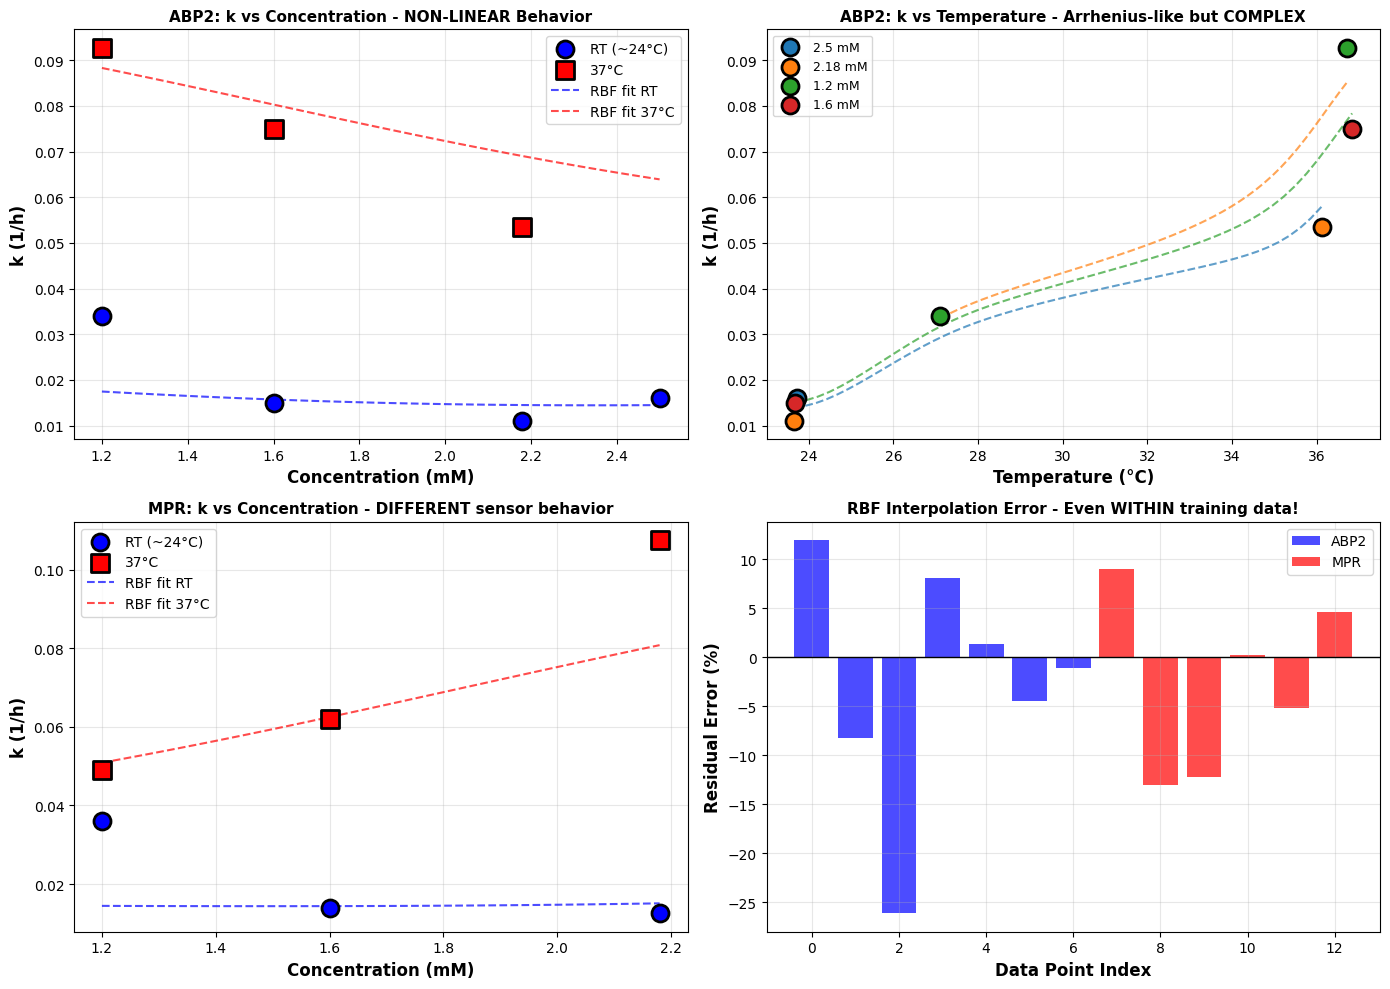


KEY OBSERVATIONS - WHY RBF INTERPOLATION IS INADEQUATE:
1. NON-LINEAR k vs Concentration: No simple pattern
2. SENSOR-DEPENDENT behavior: ABP2 ≠ MPR (different physics?)
3. COMPLEX temperature dependence: Not pure Arrhenius
4. SPARSE DATA: Only 4-5 points per sensor - huge uncertainty!
5. RBF has NO physical constraints - can predict nonsense!

→ Solution: Physics-Informed Neural Networks (PINNs)
  - Embed Arrhenius equation, mass balance, gas laws
  - Learn sensor-specific corrections
  - Quantify uncertainty in predictions


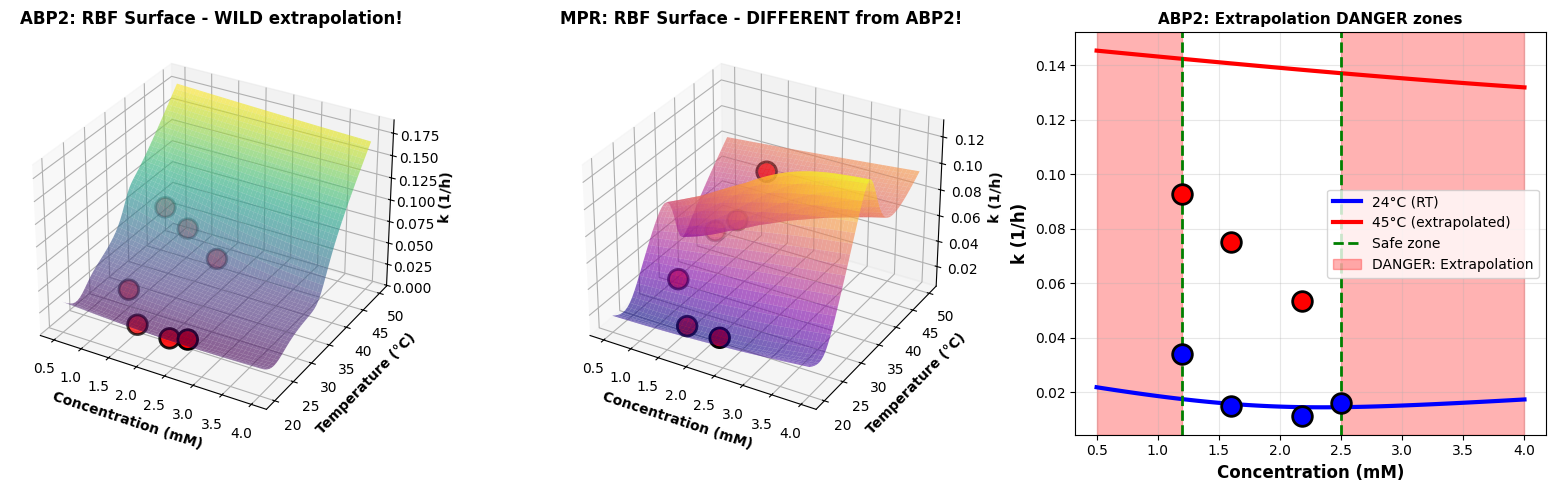


EXTRAPOLATION FAILURE ANALYSIS:
Training data: 7 ABP2 points, 6 MPR points
Safe range: Conc [1.20, 2.50] mM
            Temp [23.7, 36.8] °C

Outside this range:
  ⚠️ RBF creates ARBITRARY smooth surface
  ⚠️ NO physical meaning (can predict negative k!)
  ⚠️ NO uncertainty quantification
  ⚠️ Different sensors = different surfaces (inconsistent)

→ Need physics-based model with extrapolation capability!


interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=4.0, min=0.5), FloatSlider(value=25.…

<function __main__.interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2', V_sol_mL=6.0, V_head_mL=4.0)>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from scipy.interpolate import Rbf
from ipywidgets import interact, FloatSlider, Dropdown
from mpl_toolkits.mplot3d import Axes3D

R = 8.314
R_Latm = 0.082057
ETA_ABP2 = 0.95
ETA_MPR = 0.875

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

csv_files = [f for f in glob(f"{folder}/M*.csv")]

data = {}
for f in csv_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()
    data[Path(f).stem] = df
    print(f"✓ Loaded: {Path(f).stem}")

meta = []
conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

for name, df in data.items():
    sample, temp_label, sensor = name.split('_')
    k_col = [col for col in df.columns if 'FO-k (1/h)' in col][0]
    temp_K = df['Temperature (K)'].iloc[0]

    meta.append({
        'sample': sample,
        'conc': conc_map[sample],
        'temp_K': temp_K,
        'temp_C': temp_K - 273.15,
        'sensor': sensor,
        'k': df[k_col].iloc[0]
    })

meta = pd.DataFrame(meta)
print(meta)

meta_abp2 = meta[meta['sensor'] == 'ABP2']
rbf_abp2 = Rbf(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
                function='multiquadric', smooth=0.1)

meta_mpr = meta[meta['sensor'] == 'MPR']
rbf_mpr = Rbf(meta_mpr['conc'], meta_mpr['temp_C'], meta_mpr['k'],
            function='multiquadric', smooth=0.1)

conc_min = meta['conc'].min()
conc_max = meta['conc'].max()
temp_min = meta['temp_C'].min()
temp_max = meta['temp_C'].max()

def analyze_k_behavior():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: k vs Concentration (ABP2)
    ax1 = axes[0, 0]
    meta_abp2_rt = meta_abp2[meta_abp2['temp_C'] < 30]
    meta_abp2_37 = meta_abp2[meta_abp2['temp_C'] > 30]

    ax1.scatter(meta_abp2_rt['conc'], meta_abp2_rt['k'], s=150, marker='o',
                color='blue', label='RT (~24°C)', zorder=3, edgecolors='black', linewidth=2)
    ax1.scatter(meta_abp2_37['conc'], meta_abp2_37['k'], s=150, marker='s',
                color='red', label='37°C', zorder=3, edgecolors='black', linewidth=2)

    conc_range = np.linspace(meta_abp2['conc'].min(), meta_abp2['conc'].max(), 100)
    k_pred_rt = [rbf_abp2(c, 24) for c in conc_range]
    k_pred_37 = [rbf_abp2(c, 37) for c in conc_range]

    ax1.plot(conc_range, k_pred_rt, 'b--', alpha=0.7, label='RBF fit RT')
    ax1.plot(conc_range, k_pred_37, 'r--', alpha=0.7, label='RBF fit 37°C')

    ax1.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax1.set_title('ABP2: k vs Concentration - NON-LINEAR Behavior', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)

    # Plot 2: k vs Temperature (ABP2)
    ax2 = axes[0, 1]
    for conc in meta_abp2['conc'].unique():
        data_conc = meta_abp2[meta_abp2['conc'] == conc]
        ax2.scatter(data_conc['temp_C'], data_conc['k'], s=150,
                    label=f'{conc} mM', zorder=3, edgecolors='black', linewidth=2)

        if len(data_conc) > 1:
            temp_range = np.linspace(data_conc['temp_C'].min(), data_conc['temp_C'].max(), 50)
            k_pred = [rbf_abp2(conc, t) for t in temp_range]
            ax2.plot(temp_range, k_pred, '--', alpha=0.7)

    ax2.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax2.set_title('ABP2: k vs Temperature - Arrhenius-like but COMPLEX', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    # Plot 3: k vs Concentration (MPR)
    ax3 = axes[1, 0]
    meta_mpr_rt = meta_mpr[meta_mpr['temp_C'] < 30]
    meta_mpr_37 = meta_mpr[meta_mpr['temp_C'] > 30]

    ax3.scatter(meta_mpr_rt['conc'], meta_mpr_rt['k'], s=150, marker='o',
                color='blue', label='RT (~24°C)', zorder=3, edgecolors='black', linewidth=2)
    ax3.scatter(meta_mpr_37['conc'], meta_mpr_37['k'], s=150, marker='s',
                color='red', label='37°C', zorder=3, edgecolors='black', linewidth=2)

    conc_range_mpr = np.linspace(meta_mpr['conc'].min(), meta_mpr['conc'].max(), 100)
    k_pred_rt_mpr = [rbf_mpr(c, 24) for c in conc_range_mpr]
    k_pred_37_mpr = [rbf_mpr(c, 37) for c in conc_range_mpr]

    ax3.plot(conc_range_mpr, k_pred_rt_mpr, 'b--', alpha=0.7, label='RBF fit RT')
    ax3.plot(conc_range_mpr, k_pred_37_mpr, 'r--', alpha=0.7, label='RBF fit 37°C')

    ax3.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax3.set_title('MPR: k vs Concentration - DIFFERENT sensor behavior', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)

    # Plot 4: Residuals showing non-linearity
    ax4 = axes[1, 1]

    residuals_abp2 = []
    for _, row in meta_abp2.iterrows():
        k_pred = rbf_abp2(row['conc'], row['temp_C'])
        residuals_abp2.append((row['k'] - k_pred) / row['k'] * 100)

    residuals_mpr = []
    for _, row in meta_mpr.iterrows():
        k_pred = rbf_mpr(row['conc'], row['temp_C'])
        residuals_mpr.append((row['k'] - k_pred) / row['k'] * 100)

    ax4.bar(range(len(residuals_abp2)), residuals_abp2, color='blue', alpha=0.7, label='ABP2')
    ax4.bar(range(len(residuals_abp2), len(residuals_abp2) + len(residuals_mpr)),
            residuals_mpr, color='red', alpha=0.7, label='MPR')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax4.set_xlabel('Data Point Index', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Residual Error (%)', fontsize=12, fontweight='bold')
    ax4.set_title('RBF Interpolation Error - Even WITHIN training data!', fontsize=11, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()



def visualize_extrapolation_failure():
    fig = plt.figure(figsize=(16, 5))

    # 3D surface for ABP2
    ax1 = fig.add_subplot(131, projection='3d')

    conc_grid = np.linspace(0.5, 4.0, 50)
    temp_grid = np.linspace(20, 50, 50)
    C, T = np.meshgrid(conc_grid, temp_grid)
    K = np.zeros_like(C)

    for i in range(len(temp_grid)):
        for j in range(len(conc_grid)):
            K[i, j] = rbf_abp2(C[i, j], T[i, j])

    surf = ax1.plot_surface(C, T, K, cmap='viridis', alpha=0.6)

    ax1.scatter(meta_abp2['conc'], meta_abp2['temp_C'], meta_abp2['k'],
                color='red', s=200, marker='o', edgecolors='black', linewidth=2, label='Training data')

    ax1.set_xlabel('Concentration (mM)', fontweight='bold')
    ax1.set_ylabel('Temperature (°C)', fontweight='bold')
    ax1.set_zlabel('k (1/h)', fontweight='bold')
    ax1.set_title('ABP2: RBF Surface - WILD extrapolation!', fontweight='bold')

    # 3D surface for MPR
    ax2 = fig.add_subplot(132, projection='3d')

    K_mpr = np.zeros_like(C)
    for i in range(len(temp_grid)):
        for j in range(len(conc_grid)):
            K_mpr[i, j] = rbf_mpr(C[i, j], T[i, j])

    surf2 = ax2.plot_surface(C, T, K_mpr, cmap='plasma', alpha=0.6)

    ax2.scatter(meta_mpr['conc'], meta_mpr['temp_C'], meta_mpr['k'],
                color='red', s=200, marker='o', edgecolors='black', linewidth=2)

    ax2.set_xlabel('Concentration (mM)', fontweight='bold')
    ax2.set_ylabel('Temperature (°C)', fontweight='bold')
    ax2.set_zlabel('k (1/h)', fontweight='bold')
    ax2.set_title('MPR: RBF Surface - DIFFERENT from ABP2!', fontweight='bold')

    # Extrapolation danger zone
    ax3 = fig.add_subplot(133)

    conc_test = np.linspace(0.5, 4.0, 100)
    k_pred_24 = [rbf_abp2(c, 24) for c in conc_test]
    k_pred_45 = [rbf_abp2(c, 45) for c in conc_test]

    ax3.plot(conc_test, k_pred_24, 'b-', linewidth=3, label='24°C (RT)')
    ax3.plot(conc_test, k_pred_45, 'r-', linewidth=3, label='45°C (extrapolated)')

    ax3.scatter(meta_abp2[meta_abp2['temp_C'] < 30]['conc'],
                meta_abp2[meta_abp2['temp_C'] < 30]['k'],
                s=200, color='blue', edgecolors='black', linewidth=2, zorder=5)
    ax3.scatter(meta_abp2[meta_abp2['temp_C'] > 30]['conc'],
                meta_abp2[meta_abp2['temp_C'] > 30]['k'],
                s=200, color='red', edgecolors='black', linewidth=2, zorder=5)

    ax3.axvline(x=meta_abp2['conc'].min(), color='green', linestyle='--', linewidth=2, label='Safe zone')
    ax3.axvline(x=meta_abp2['conc'].max(), color='green', linestyle='--', linewidth=2)
    ax3.axvspan(0.5, meta_abp2['conc'].min(), alpha=0.3, color='red', label='DANGER: Extrapolation')
    ax3.axvspan(meta_abp2['conc'].max(), 4.0, alpha=0.3, color='red')

    ax3.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax3.set_title('ABP2: Extrapolation DANGER zones', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def check_extrapolation(conc_mM, temp_C, sensor):
    sensor_meta = meta[meta['sensor'] == sensor]
    conc_min_sensor = sensor_meta['conc'].min()
    conc_max_sensor = sensor_meta['conc'].max()
    temp_min_sensor = sensor_meta['temp_C'].min()
    temp_max_sensor = sensor_meta['temp_C'].max()

    is_extrapolating = (conc_mM < conc_min_sensor or conc_mM > conc_max_sensor or
                        temp_C < temp_min_sensor or temp_C > temp_max_sensor)

    warnings = []
    if conc_mM < conc_min_sensor:
        warnings.append(f"⚠️ Conc {conc_mM:.2f} < training min {conc_min_sensor:.2f} mM")
    elif conc_mM > conc_max_sensor:
        warnings.append(f"⚠️ Conc {conc_mM:.2f} > training max {conc_max_sensor:.2f} mM")

    if temp_C < temp_min_sensor:
        warnings.append(f"⚠️ Temp {temp_C:.1f} < training min {temp_min_sensor:.1f} °C")
    elif temp_C > temp_max_sensor:
        warnings.append(f"⚠️ Temp {temp_C:.1f} > training max {temp_max_sensor:.1f} °C")

    return is_extrapolating, warnings, (conc_min_sensor, conc_max_sensor, temp_min_sensor, temp_max_sensor)

def predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL):
    k = rbf_abp2(conc_mM, temp_C) if sensor == 'ABP2' else rbf_mpr(conc_mM, temp_C)
    eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

    V_sol_L = V_sol_mL * 1e-3
    V_head_L = V_head_mL * 1e-3
    temp_K = temp_C + 273.15

    O2_theoretical_umol = conc_mM * V_sol_mL

    N0_mol = (conc_mM * 1e-3) * V_sol_L * eta
    N0_umol = N0_mol * 1e6

    Pmax_Pa = (N0_mol * R * temp_K) / (V_head_L * 1e-3)
    Pmax_kPa = Pmax_Pa / 1000.0

    t = np.linspace(0, 250, 1000)
    P_kPa = Pmax_kPa * (1 - np.exp(-k * t))
    O2_umol = ((P_kPa / 101.325) * V_head_L) / (R_Latm * temp_K) * 1e6

    return t, P_kPa, O2_umol, k, N0_umol, Pmax_kPa, O2_theoretical_umol

def interactive_predict(conc_mM=2.0, temp_C=25.0, sensor='ABP2',
                        V_sol_mL=6.0, V_head_mL=4.0):

    is_extrap, warnings, bounds = check_extrapolation(conc_mM, temp_C, sensor)
    conc_min_s, conc_max_s, temp_min_s, temp_max_s = bounds

    t, P, O2, k, N0, Pmax, O2_theo = predict_o2(conc_mM, temp_C, sensor, V_sol_mL, V_head_mL)
    eta = ETA_ABP2 if sensor == 'ABP2' else ETA_MPR

    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'orange' if is_extrap else 'blue'
    linestyle = '--' if is_extrap else '-'

    ax1.plot(t, P, color=color, lw=2.5, linestyle=linestyle, label='Pressure')
    ax1.set_xlabel('Time (h)', fontsize=12)
    ax1.set_ylabel('Pressure (kPa)', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(t, O2, 'r--', lw=2.5, label='O₂ released')
    ax2.axhline(y=O2_theo, color='gray', linestyle=':', lw=2, label='Theoretical max')
    ax2.set_ylabel('O₂ released (µmol)', color='r', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc='lower right', fontsize=9)

    status = "⚠️ EXTRAPOLATION" if is_extrap else "✓ INTERPOLATION"
    plt.title(f'{sensor} | {conc_mM:.2f} mM @ {temp_C:.1f}°C | k={k:.4f} 1/h | {status}',
            fontsize=11, color='red' if is_extrap else 'black')
    plt.tight_layout()
    plt.show()

    print(f"{'='*70}")
    if is_extrap:
        print("⚠️⚠️⚠️ EXTRAPOLATION WARNING - PREDICTION UNRELIABLE ⚠️⚠️⚠️")
        print(f"{'='*70}")
        for warning in warnings:
            print(warning)
        print(f"\n{sensor} Training range: Conc [{conc_min_s:.2f}, {conc_max_s:.2f}] mM, "
            f"Temp [{temp_min_s:.1f}, {temp_max_s:.1f}] °C")
        print("RBF interpolation is NOT physics-based and will FAIL outside training data!")
        print("Consider: Physics-Informed Neural Networks (PINNs) for better extrapolation")
    else:
        print(f"✓ SAFE INTERPOLATION - Within {sensor} training bounds")
        print(f"  Conc range: [{conc_min_s:.2f}, {conc_max_s:.2f}] mM")
        print(f"  Temp range: [{temp_min_s:.1f}, {temp_max_s:.1f}] °C")

    print(f"{'='*70}")
    print(f"Sensor: {sensor:5s} | k: {k:.4e} 1/h | η: {eta:.3f}")
    print(f"N₀: {N0:.2f} µmol | Pmax: {Pmax:.2f} kPa | Max O₂: {O2[-1]:.2f} µmol")
    print(f"Theoretical max O₂: {O2_theo:.2f} µmol | Efficiency: {(N0/O2_theo)*100:.1f}%")
    print(f"{'='*70}")

print("\n" + "="*60)
print("EMPIRICAL O2 RELEASE MODEL - DUAL SENSOR")
print("="*60)
print(f"Loaded {len(data)} datasets")
print(f"ABP2 points: {len(meta_abp2)} | MPR points: {len(meta_mpr)}")
print("="*60)

print("\n🔬 GENERATING ANALYSIS PLOTS...")
analyze_k_behavior()
visualize_extrapolation_failure()

interact(
    interactive_predict,
    conc_mM=FloatSlider(value=2.0, min=0.5, max=4.0, step=0.1, description='Conc (mM)'),
    temp_C=FloatSlider(value=25.0, min=20.0, max=50.0, step=0.5, description='Temp (°C)'),
    sensor=Dropdown(options=['ABP2', 'MPR'], value='ABP2', description='Sensor'),
    V_sol_mL=FloatSlider(value=6.0, min=1.0, max=20.0, step=0.5, description='V_sol (mL)'),
    V_head_mL=FloatSlider(value=4.0, min=1.0, max=20.0, step=0.5, description='V_head (mL)')
)

 ABP2:
 At RT, k is nearly flat ~0.016 1/h across all concentrations. Suggests mass transfer limitations or sensor saturation at high concentrations


 MPR:
 - OPPOSITE trend to ABP2! At 37°C, k increases with concentration
  - This proves sensor-dependent physics - ABP2 ≠ MPR measuring different things
  - Gauge vs absolute pressure affects mass transfer differently?


Next steps:

1. Classic with arrhenius dependence and how the k changes then
2. Possibility to put MLP to predict k value
3. Moving to other options like ML

 Both sensors report the same total pressure drop (efficiency), but k comes from the shape of the decay. k is therefore sensitive to each sensor’s
 dynamic response and calibration, whereas yield is not.

✓ Loaded: M1_RT_ABP2
✓ Loaded: M2_37C_ABP2
✓ Loaded: M2_37C_MPR
✓ Loaded: M2_RT_ABP2
✓ Loaded: M2_RT_MPR
✓ Loaded: M3_37C_ABP2
✓ Loaded: M3_37C_MPR
✓ Loaded: M3_RT_ABP2
✓ Loaded: M3_RT_MPR
✓ Loaded: M4_37C_ABP2
✓ Loaded: M4_37C_MPR
✓ Loaded: M4_RT_ABP2
✓ Loaded: M4_RT_MPR

EXTRACTED K VALUES - FO vs ARR_FO
   sample  conc      temp_K     temp_C sensor    k_FO  k_ARR_FO
0      M1  2.50  296.873987  23.723987   ABP2  0.0160  0.015200
1      M2  2.18  309.268833  36.118833   ABP2  0.0535  0.053500
2      M2  2.18  309.268833  36.118833    MPR  0.1074  0.107400
3      M2  2.18  296.810000  23.660000   ABP2  0.0111  0.012400
4      M2  2.18  296.920294  23.770294    MPR  0.0126  0.014000
5      M3  1.20  309.874433  36.724433   ABP2  0.0927  0.092700
6      M3  1.20  309.875100  36.725100    MPR  0.0490  0.049100
7      M3  1.20  300.260000  27.110000   ABP2  0.0340  0.032600
8      M3  1.20  300.269960  27.119960    MPR  0.0360  0.033500
9      M4  1.60  309.990766  36.840766   ABP2  0.075

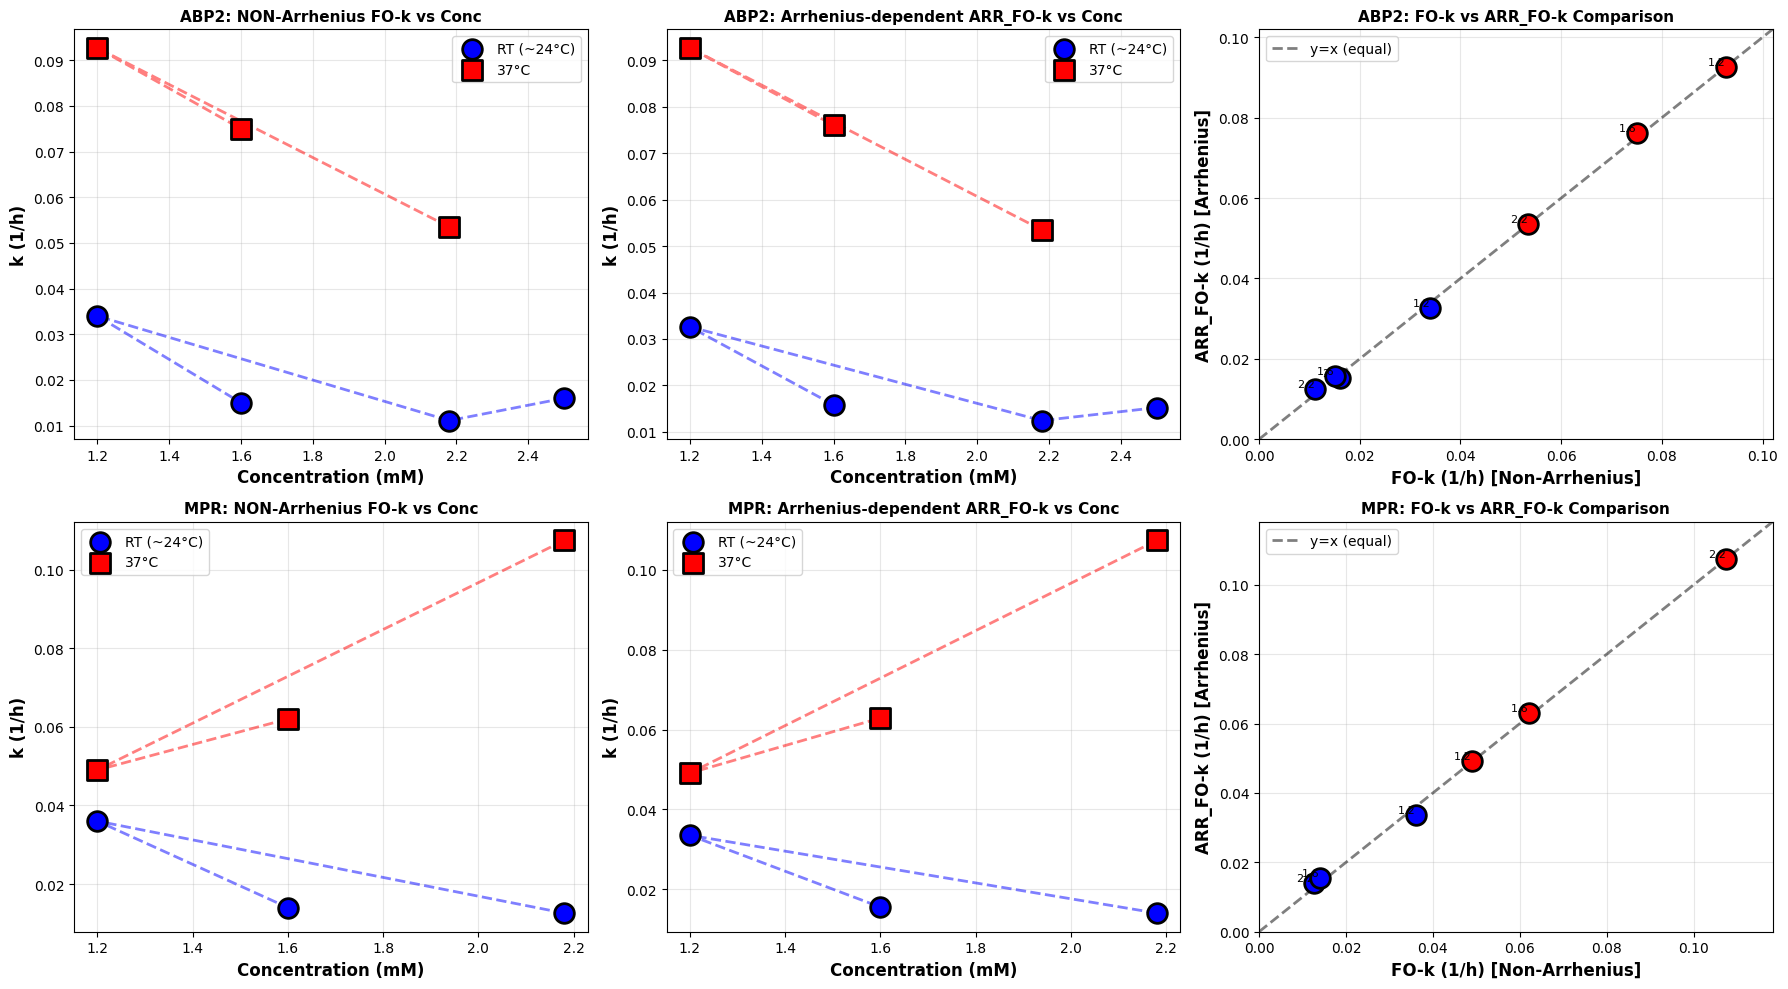


COMPARISON ANALYSIS: FO-k vs ARR_FO-k

ABP2:
  Mean difference: 3.94%
  Max difference: 11.71%
  Points where ARR_FO > FO: 3/7
  Points where ARR_FO < FO: 2/7

MPR:
  Mean difference: 5.07%
  Max difference: 11.11%
  Points where ARR_FO > FO: 4/6
  Points where ARR_FO < FO: 1/6


IndexError: index 4 is out of bounds for axis 0 with size 4

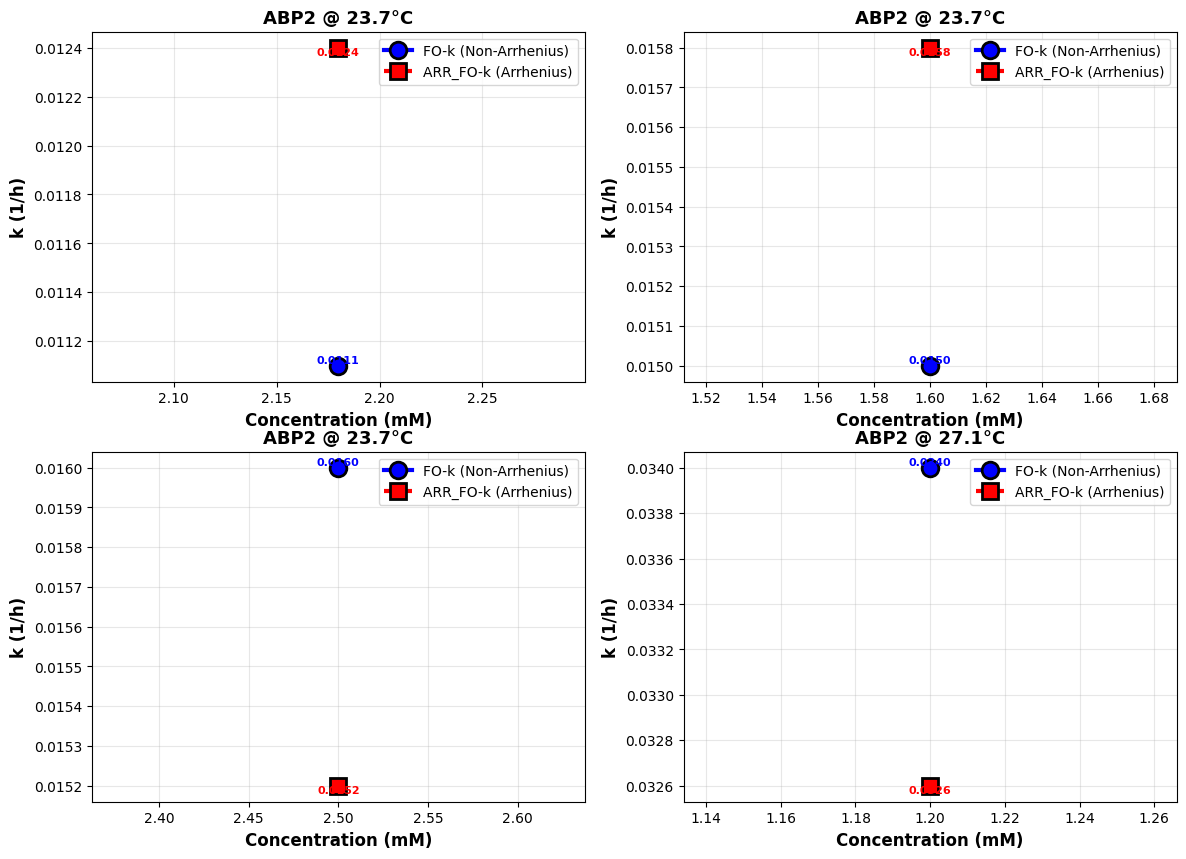

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

folder = r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous"

csv_files = [f for f in glob(f"{folder}/M*.csv")]

data = {}
for f in csv_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()
    data[Path(f).stem] = df
    print(f"✓ Loaded: {Path(f).stem}")

meta = []
conc_map = {'M1': 2.5, 'M2': 2.18, 'M3': 1.2, 'M4': 1.6}

for name, df in data.items():
    sample, temp_label, sensor = name.split('_')

    fo_k_col = [col for col in df.columns if 'FO-k (1/h)' in col and 'ARR' not in col][0]
    arr_fo_k_col = [col for col in df.columns if 'ARR_FO-k (1/h)' in col][0]

    temp_K = df['Temperature (K)'].iloc[0]

    meta.append({
        'sample': sample,
        'conc': conc_map[sample],
        'temp_K': temp_K,
        'temp_C': temp_K - 273.15,
        'sensor': sensor,
        'k_FO': df[fo_k_col].iloc[0],
        'k_ARR_FO': df[arr_fo_k_col].iloc[0]
    })

meta = pd.DataFrame(meta)
print("\n" + "="*80)
print("EXTRACTED K VALUES - FO vs ARR_FO")
print("="*80)
print(meta)

def compare_arrhenius_vs_nonarrhenius():

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    meta_abp2 = meta[meta['sensor'] == 'ABP2']
    meta_mpr = meta[meta['sensor'] == 'MPR']

    # Plot 1: ABP2 - FO-k vs Concentration
    ax1 = axes[0, 0]
    meta_abp2_rt = meta_abp2[meta_abp2['temp_C'] < 30]
    meta_abp2_37 = meta_abp2[meta_abp2['temp_C'] > 30]

    ax1.scatter(meta_abp2_rt['conc'], meta_abp2_rt['k_FO'], s=200, marker='o',
                color='blue', label='RT (~24°C)', zorder=3, edgecolors='black', linewidth=2)
    ax1.scatter(meta_abp2_37['conc'], meta_abp2_37['k_FO'], s=200, marker='s',
                color='red', label='37°C', zorder=3, edgecolors='black', linewidth=2)
    ax1.plot(meta_abp2_rt['conc'], meta_abp2_rt['k_FO'], 'b--', alpha=0.5, linewidth=2)
    ax1.plot(meta_abp2_37['conc'], meta_abp2_37['k_FO'], 'r--', alpha=0.5, linewidth=2)

    ax1.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax1.set_title('ABP2: NON-Arrhenius FO-k vs Conc', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)

    # Plot 2: ABP2 - ARR_FO-k vs Concentration
    ax2 = axes[0, 1]
    ax2.scatter(meta_abp2_rt['conc'], meta_abp2_rt['k_ARR_FO'], s=200, marker='o',
                color='blue', label='RT (~24°C)', zorder=3, edgecolors='black', linewidth=2)
    ax2.scatter(meta_abp2_37['conc'], meta_abp2_37['k_ARR_FO'], s=200, marker='s',
                color='red', label='37°C', zorder=3, edgecolors='black', linewidth=2)
    ax2.plot(meta_abp2_rt['conc'], meta_abp2_rt['k_ARR_FO'], 'b--', alpha=0.5, linewidth=2)
    ax2.plot(meta_abp2_37['conc'], meta_abp2_37['k_ARR_FO'], 'r--', alpha=0.5, linewidth=2)

    ax2.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax2.set_title('ABP2: Arrhenius-dependent ARR_FO-k vs Conc', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    # Plot 3: ABP2 - Direct comparison
    ax3 = axes[0, 2]
    for idx, row in meta_abp2.iterrows():
        color = 'blue' if row['temp_C'] < 30 else 'red'
        ax3.scatter(row['k_FO'], row['k_ARR_FO'], s=200, color=color,
                    edgecolors='black', linewidth=2, zorder=3)
        ax3.text(row['k_FO'], row['k_ARR_FO'], f"{row['conc']:.1f}",
                fontsize=8, ha='right', va='bottom')

    k_max = max(meta_abp2['k_FO'].max(), meta_abp2['k_ARR_FO'].max()) * 1.1
    ax3.plot([0, k_max], [0, k_max], 'k--', alpha=0.5, linewidth=2, label='y=x (equal)')

    ax3.set_xlabel('FO-k (1/h) [Non-Arrhenius]', fontsize=12, fontweight='bold')
    ax3.set_ylabel('ARR_FO-k (1/h) [Arrhenius]', fontsize=12, fontweight='bold')
    ax3.set_title('ABP2: FO-k vs ARR_FO-k Comparison', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)
    ax3.set_xlim(0, k_max)
    ax3.set_ylim(0, k_max)

    # Plot 4: MPR - FO-k vs Concentration
    ax4 = axes[1, 0]
    meta_mpr_rt = meta_mpr[meta_mpr['temp_C'] < 30]
    meta_mpr_37 = meta_mpr[meta_mpr['temp_C'] > 30]

    ax4.scatter(meta_mpr_rt['conc'], meta_mpr_rt['k_FO'], s=200, marker='o',
                color='blue', label='RT (~24°C)', zorder=3, edgecolors='black', linewidth=2)
    ax4.scatter(meta_mpr_37['conc'], meta_mpr_37['k_FO'], s=200, marker='s',
                color='red', label='37°C', zorder=3, edgecolors='black', linewidth=2)
    ax4.plot(meta_mpr_rt['conc'], meta_mpr_rt['k_FO'], 'b--', alpha=0.5, linewidth=2)
    ax4.plot(meta_mpr_37['conc'], meta_mpr_37['k_FO'], 'r--', alpha=0.5, linewidth=2)

    ax4.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax4.set_title('MPR: NON-Arrhenius FO-k vs Conc', fontsize=11, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3)

    # Plot 5: MPR - ARR_FO-k vs Concentration
    ax5 = axes[1, 1]
    ax5.scatter(meta_mpr_rt['conc'], meta_mpr_rt['k_ARR_FO'], s=200, marker='o',
                color='blue', label='RT (~24°C)', zorder=3, edgecolors='black', linewidth=2)
    ax5.scatter(meta_mpr_37['conc'], meta_mpr_37['k_ARR_FO'], s=200, marker='s',
                color='red', label='37°C', zorder=3, edgecolors='black', linewidth=2)
    ax5.plot(meta_mpr_rt['conc'], meta_mpr_rt['k_ARR_FO'], 'b--', alpha=0.5, linewidth=2)
    ax5.plot(meta_mpr_37['conc'], meta_mpr_37['k_ARR_FO'], 'r--', alpha=0.5, linewidth=2)

    ax5.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
    ax5.set_title('MPR: Arrhenius-dependent ARR_FO-k vs Conc', fontsize=11, fontweight='bold')
    ax5.legend(fontsize=10)
    ax5.grid(alpha=0.3)

    # Plot 6: MPR - Direct comparison
    ax6 = axes[1, 2]
    for idx, row in meta_mpr.iterrows():
        color = 'blue' if row['temp_C'] < 30 else 'red'
        ax6.scatter(row['k_FO'], row['k_ARR_FO'], s=200, color=color,
                    edgecolors='black', linewidth=2, zorder=3)
        ax6.text(row['k_FO'], row['k_ARR_FO'], f"{row['conc']:.1f}",
                fontsize=8, ha='right', va='bottom')

    k_max_mpr = max(meta_mpr['k_FO'].max(), meta_mpr['k_ARR_FO'].max()) * 1.1
    ax6.plot([0, k_max_mpr], [0, k_max_mpr], 'k--', alpha=0.5, linewidth=2, label='y=x (equal)')

    ax6.set_xlabel('FO-k (1/h) [Non-Arrhenius]', fontsize=12, fontweight='bold')
    ax6.set_ylabel('ARR_FO-k (1/h) [Arrhenius]', fontsize=12, fontweight='bold')
    ax6.set_title('MPR: FO-k vs ARR_FO-k Comparison', fontsize=11, fontweight='bold')
    ax6.legend(fontsize=10)
    ax6.grid(alpha=0.3)
    ax6.set_xlim(0, k_max_mpr)
    ax6.set_ylim(0, k_max_mpr)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("COMPARISON ANALYSIS: FO-k vs ARR_FO-k")
    print("="*80)

    for sensor in ['ABP2', 'MPR']:
        sensor_meta = meta[meta['sensor'] == sensor]
        diff = ((sensor_meta['k_ARR_FO'] - sensor_meta['k_FO']) / sensor_meta['k_FO'] * 100).abs()

        print(f"\n{sensor}:")
        print(f"  Mean difference: {diff.mean():.2f}%")
        print(f"  Max difference: {diff.max():.2f}%")
        print(f"  Points where ARR_FO > FO: {(sensor_meta['k_ARR_FO'] > sensor_meta['k_FO']).sum()}/{len(sensor_meta)}")
        print(f"  Points where ARR_FO < FO: {(sensor_meta['k_ARR_FO'] < sensor_meta['k_FO']).sum()}/{len(sensor_meta)}")

def plot_individual_sensor_temp():

    sensors = meta['sensor'].unique()
    temps = meta['temp_C'].unique()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_idx = 0
    for sensor in sensors:
        for temp in sorted(temps):
            sensor_temp_data = meta[(meta['sensor'] == sensor) & (meta['temp_C'] == temp)]

            if len(sensor_temp_data) == 0:
                continue

            ax = axes.flat[plot_idx]

            conc_sorted = sensor_temp_data.sort_values('conc')

            ax.plot(conc_sorted['conc'], conc_sorted['k_FO'], 'o-',
                    color='blue', linewidth=3, markersize=12,
                    label='FO-k (Non-Arrhenius)', markeredgecolor='black', markeredgewidth=2)
            ax.plot(conc_sorted['conc'], conc_sorted['k_ARR_FO'], 's--',
                    color='red', linewidth=3, markersize=12,
                    label='ARR_FO-k (Arrhenius)', markeredgecolor='black', markeredgewidth=2)

            for _, row in conc_sorted.iterrows():
                ax.text(row['conc'], row['k_FO'], f"{row['k_FO']:.4f}",
                        fontsize=8, ha='center', va='bottom', color='blue', fontweight='bold')
                ax.text(row['conc'], row['k_ARR_FO'], f"{row['k_ARR_FO']:.4f}",
                        fontsize=8, ha='center', va='top', color='red', fontweight='bold')

            ax.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
            ax.set_ylabel('k (1/h)', fontsize=12, fontweight='bold')
            ax.set_title(f'{sensor} @ {temp:.1f}°C', fontsize=13, fontweight='bold')
            ax.legend(fontsize=10, loc='best')
            ax.grid(alpha=0.3)

            plot_idx += 1

    for idx in range(plot_idx, 4):
        axes.flat[idx].axis('off')

    plt.tight_layout()
    plt.show()

def arrhenius_plot():

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    meta_abp2 = meta[meta['sensor'] == 'ABP2']
    meta_mpr = meta[meta['sensor'] == 'MPR']

    for conc in meta_abp2['conc'].unique():
        data_conc = meta_abp2[meta_abp2['conc'] == conc].sort_values('temp_K')
        if len(data_conc) > 1:
            inv_T = 1000 / data_conc['temp_K']
            ln_k_FO = np.log(data_conc['k_FO'])
            ln_k_ARR = np.log(data_conc['k_ARR_FO'])

            ax1.scatter(inv_T, ln_k_FO, s=150, marker='o',
                        label=f'{conc} mM (FO)', edgecolors='black', linewidth=2)
            ax1.plot(inv_T, ln_k_FO, '--', alpha=0.5)

            ax1.scatter(inv_T, ln_k_ARR, s=150, marker='s',
                        label=f'{conc} mM (ARR_FO)', edgecolors='black', linewidth=2)
            ax1.plot(inv_T, ln_k_ARR, ':', alpha=0.5)

    ax1.set_xlabel('1000/T (1/K)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('ln(k)', fontsize=12, fontweight='bold')
    ax1.set_title('ABP2: Arrhenius Plot - FO vs ARR_FO', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8, ncol=2)
    ax1.grid(alpha=0.3)

    for conc in meta_mpr['conc'].unique():
        data_conc = meta_mpr[meta_mpr['conc'] == conc].sort_values('temp_K')
        if len(data_conc) > 1:
            inv_T = 1000 / data_conc['temp_K']
            ln_k_FO = np.log(data_conc['k_FO'])
            ln_k_ARR = np.log(data_conc['k_ARR_FO'])

            ax2.scatter(inv_T, ln_k_FO, s=150, marker='o',
                        label=f'{conc} mM (FO)', edgecolors='black', linewidth=2)
            ax2.plot(inv_T, ln_k_FO, '--', alpha=0.5)

            ax2.scatter(inv_T, ln_k_ARR, s=150, marker='s',
                        label=f'{conc} mM (ARR_FO)', edgecolors='black', linewidth=2)
            ax2.plot(inv_T, ln_k_ARR, ':', alpha=0.5)

    ax2.set_xlabel('1000/T (1/K)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('ln(k)', fontsize=12, fontweight='bold')
    ax2.set_title('MPR: Arrhenius Plot - FO vs ARR_FO', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8, ncol=2)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("ARRHENIUS PLOT INTERPRETATION:")
    print("="*80)
    print("If linear → Pure Arrhenius behavior (k = A*exp(-Ea/RT))")
    print("If NOT linear → Complex kinetics (concentration-dependent Ea, or non-Arrhenius)")
    print("FO-k (circles, dashed): Independent temperature fits per condition")
    print("ARR_FO-k (squares, dotted): Constrained Arrhenius fits with shared A, Ea")
    print("="*80)

print("\n" + "="*80)
print("GENERATING ARRHENIUS vs NON-ARRHENIUS COMPARISON PLOTS...")
print("="*80)

compare_arrhenius_vs_nonarrhenius()
plot_individual_sensor_temp()
arrhenius_plot()

At RT, both sensors sit near their factory-calibrated point, so they agree.


C:\Users\chand\AppData\Local\Temp\ipykernel_2668\2174106840.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="latin1", encoding_errors="replace")
C:\Users\chand\AppData\Local\Temp\ipykernel_2668\2174106840.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="latin1", encoding_errors="replace")
C:\Users\chand\AppData\Local\Temp\ipykernel_2668\2174106840.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="latin1", encoding_errors="replace")
C:\Users\chand\AppData\Local\Temp\ipykernel_2668\2174106840.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="latin1", encoding_errors="replace")


Saved C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous\pressure_overlay_37C.png


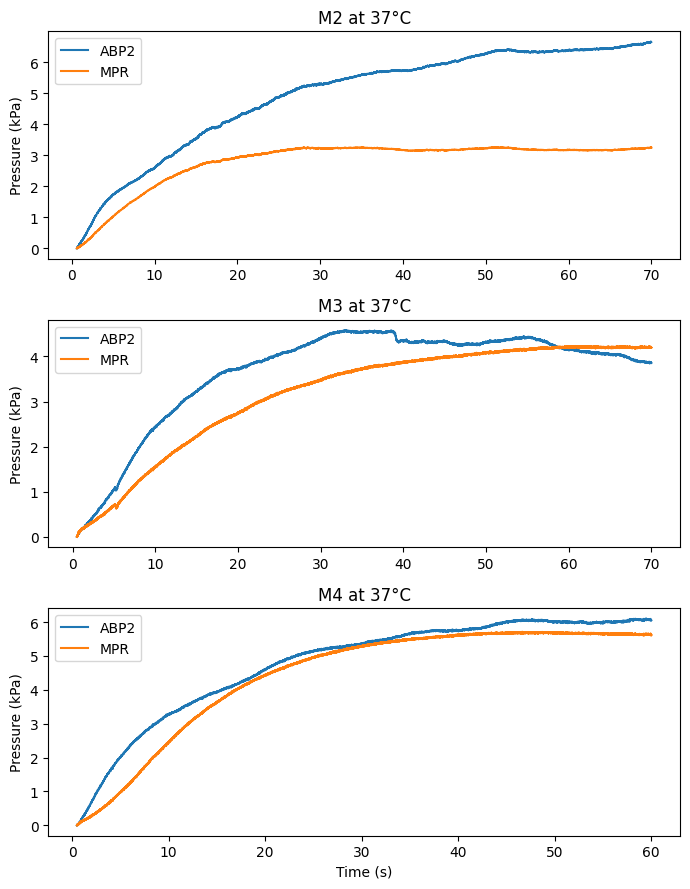

In [48]:

import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

TIME_COL = "Time (h)"
PRESSURE_COL = "Denoised pressure (kPa)"
data_dir = Path(r"C:\Users\chand\Documents\GitHub\Thesis\Miscellaneous")

def load_trace(path):
    df = pd.read_csv(path, encoding="latin1", encoding_errors="replace")
    return df[[TIME_COL, PRESSURE_COL]].dropna().sort_values(TIME_COL)

def main():
    pairs = {}
    for p in data_dir.glob("M*_37C_*.csv"):
        m = re.match(r"(M\d+)_37C_(ABP2|MPR)\.csv", p.name, re.IGNORECASE)
        if m:
            sample, sensor = m.group(1).upper(), m.group(2).upper()
            pairs.setdefault(sample, {})[sensor] = p
    pairs = {k: v for k, v in pairs.items() if "ABP2" in v and "MPR" in v}
    if not pairs:
        raise SystemExit("No 37°C ABP2/MPR pairs found in the specified directory.")

    fig, axes = plt.subplots(len(pairs), 1, figsize=(7, 3 * len(pairs)), sharex=False)
    if len(pairs) == 1:
        axes = [axes]

    for ax, (sample, files) in zip(axes, sorted(pairs.items())):
        abp2 = load_trace(files["ABP2"])
        mpr = load_trace(files["MPR"])
        merged = pd.merge_asof(
            abp2, mpr, on=TIME_COL, direction="nearest",
            suffixes=("_abp2", "_mpr")
        )
        ax.plot(merged[TIME_COL], merged[f"{PRESSURE_COL}_abp2"], label="ABP2")
        ax.plot(merged[TIME_COL], merged[f"{PRESSURE_COL}_mpr"], label="MPR")
        ax.set_title(f"{sample} at 37°C")
        ax.set_ylabel("Pressure (kPa)")
        ax.legend()

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.savefig(data_dir / "pressure_overlay_37C.png", dpi=150)
    print(f"Saved {data_dir / 'pressure_overlay_37C.png'}")

if __name__  == "__main__":
    main()


 - The drift shows up at 37°C because the MPR’s absolute sensor isn’t perfectly temperature‑compensated there: when the sensor warms, its zero/span shifts
    a bit over the first minute. At room temp that shift is tiny; at 37°C self‑heating plus the warmer ambient make it noticeable.
  - Because MPR reports absolute pressure, any small temp-induced offset/gain error moves the whole baseline; ABP2 (gauge) is less exposed to that full-
    scale offset.
  - That drift scales with how big the pressure swing is: higher concentration gives a bigger swing, so the drift pulls the curve down more, making the
    decay look faster and pushing k up with concentration. ABP2 stays steadier, so its k still falls with concentration.